# Project 04 · Card Fraud Detection AI
## EDA -> Hypothesis -> Feature Engineering -> Feature Selection -> Model Comparison -> Final Model -> Research Report


데이터셋: **PaySim** (`ai-server/data/paysim.csv`)

Target: **isFraud** (0 = 정상 거래, 1 = 이상거래/사기 의심 거래) -> Binary Classification(이진 분류) 문제



```text
EDA
  ↓
Hypothesis (가설 수립)
  ↓
Feature Engineering (파생변수 생성)
  ↓
Feature Selection
  ↓
Train / Test Split (Stratified)
  ↓
Model Comparison (Logistic Regression, Random Forest, XGBoost)
  ↓
Threshold 조정
  ↓
Final Model
  ↓
Research Report
```

> **데이터 안내**: 이 저장소에는 용량 문제로 실제 PaySim CSV가 포함되어 있지 않습니다.
> `ai-server/data/README.md` 안내에 따라 데이터를 추가한 뒤 이 노트북을 처음부터 다시 실행하세요.
> 데이터가 없어도 모든 코드 셀은 오류 없이 끝까지 실행되도록 작성되어 있으며(`DATA_AVAILABLE` 플래그로
> 각 단계를 안내), 이 경우 표/그래프는 비어 있고 "[SKIP]" 안내만 출력됩니다.


# Chapter 1. 프로젝트 소개


## 금융 이상거래 탐지(Fraud Detection)란?

전자결제/모바일 송금 서비스에서는 매초 수많은 거래가 발생합니다. 이 중 아주 일부가 계정 탈취,
자금 세탁 등 **이상거래(Fraud)** 입니다. 이상거래를 사람이 하나하나 검토하는 것은 불가능하므로,
"이 거래가 실행되기 전에 위험도가 얼마나 될까?"를 미리 예측하지 못하면 다음과 같은 문제가
생깁니다.

- 사기 거래를 놓치면(미탐) 금전적 피해와 사후 처리 비용이 발생합니다.
- 정상 거래를 사기로 잘못 판단하면(오탐) 고객이 불편을 겪고 이탈로 이어질 수 있습니다.
- 사기 비율이 매우 낮기 때문에(클래스 불균형), 아무 기준 없이 모델을 만들면 "전부 정상"으로
  예측해도 겉보기 정확도가 매우 높아 보이는 착시가 발생합니다.

그래서 "이 거래가 실행되기 전에 얼마나 위험한가?"를 미리 점수화하는 모델은 자동 검토·추가 인증
같은 운영 정책에 매우 중요하게 사용됩니다.

이 프로젝트는 Chapter 3(Seoul Bike Demand, 회귀)와 달리 정답(Target)이 연속적인 숫자가 아니라
**정상(0)/사기(1)** 두 값이므로, 회귀(Regression)가 아니라 **분류(Classification)** 문제입니다.
평가 지표도 MAE/RMSE/R²가 아니라 **Precision, Recall, F1, ROC-AUC, PR-AUC** 를 사용합니다.



## 머신러닝 Workflow


```text
데이터 수집
    ↓
EDA (탐색적 데이터 분석)
    ↓
Hypothesis (가설 수립)
    ↓
Feature Engineering (파생변수 생성)
    ↓
Feature Selection (불필요한 Feature 제거)
    ↓
Train / Test Split (Stratified)
    ↓
Model Comparison (여러 모델 비교)
    ↓
클래스 불균형 처리 + Threshold 조정
    ↓
Final Model (최종 모델 선정 및 저장)
```

## Feature Engineering의 목적

원본 5개 입력(`type`, `amount`, `oldbalanceOrg`, `oldbalanceDest`, `Hour`)을 그대로 쓰는 것보다,
컬럼들을 조합하거나 가공해서 **모델이 사기 패턴을 더 쉽게 학습할 수 있는 형태** 로 바꿔주는
작업입니다.

예를 들어 "거래 금액이 송금자 잔액의 대부분을 차지하는 경우"처럼 두 컬럼이 결합될 때만 드러나는
위험 신호는, 원본 컬럼 두 개를 각각 보는 것보다 하나의 파생변수(`AmountToSenderBalance`)로
만들어주면 모델이 훨씬 더 쉽게 학습합니다.

## Feature Selection의 목적

Feature Engineering으로 파생변수를 만들다 보면, 오히려 서로 비슷한 정보를 담은 중복 Feature가
늘어나거나, Target과 거의 관련이 없는 Feature가 섞이게 됩니다.

Feature Selection은 이렇게 늘어난 Feature 중에서

- 분산이 없어 정보량이 없는 Feature
- 다른 Feature와 거의 동일한 정보를 담은(높은 상관관계) Feature
- 모델이 실제로 중요하게 사용하지 않는 Feature

를 걸러내는 과정입니다.


# Chapter 2. EDA (Exploratory Data Analysis, 탐색적 데이터 분석)


## EDA를 왜 하는가?

EDA를 통해 우리는 다음 질문에 답할 수 있어야 합니다.

- 이 데이터는 몇 건(Row)의 거래로, 몇 개의 정보(컬럼)로 이루어져 있는가?
- 비어있는 값(결측치)이나 무한값, 음수 금액 같은 이상한 값은 없는가?
- 정상 거래와 사기 거래의 비율은 얼마나 차이 나는가(클래스 불균형)?
- 거래 유형(Type)에 따라 사기 비율은 어떻게 달라지는가?
- 거래 금액(Amount)은 정상/사기 거래에서 어떻게 다르게 분포하는가?
- 송금자/수취인의 거래 전 잔액(Balance)은 사기 여부와 어떤 관계가 있는가?
- 시간대(Hour)에 따라 거래량과 사기 비율은 어떻게 달라지는가?


In [7]:
%pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [8]:
# ---------------------------------------------------------------
# 라이브러리 불러오기
# ---------------------------------------------------------------
import sys
sys.path.append("..")  # ai-server/feature_engineering.py, train_model.py를 import하기 위함

import os
import json
import time
import platform

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, Markdown

pd.set_option("display.max_columns", 50)
plt.rcParams["figure.figsize"] = (8, 5)

# OS별 한글 폰트 설정
system_name = platform.system()

if system_name == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif system_name == "Darwin":  # macOS
    plt.rcParams["font.family"] = "AppleGothic"
else:  # Linux, Colab, Ubuntu
    plt.rcParams["font.family"] = "NanumGothic"

# 기타 Matplotlib 설정
plt.rcParams["axes.unicode_minus"] = False  # 마이너스 기호 깨짐 방지

pd.set_option("display.max_columns", 100)

RANDOM_STATE = 42
print("환경 설정 완료")


환경 설정 완료


In [9]:
# ---------------------------------------------------------------
# 데이터 파일 탐색
# data/ 폴더에서 아래 순서로 PaySim 파일을 찾습니다.
# (자세한 정책은 ai-server/data/README.md 참고)
# ---------------------------------------------------------------
DATA_DIR = "../data"

CANDIDATE_DATA_FILES = [
    "paysim.csv",
    "paysim_sample.csv",
    "PS_20174392719_1491204439457_log.csv",
    "PaySim.csv",
    "fraud.csv",
]


def find_data_file():
    for name in CANDIDATE_DATA_FILES:
        path = os.path.join(DATA_DIR, name)
        if os.path.exists(path):
            return path
    return None


DATA_PATH = find_data_file()
DATA_AVAILABLE = DATA_PATH is not None

if DATA_AVAILABLE:
    file_size_mb = os.path.getsize(DATA_PATH) / (1024 ** 2)
    print(f"데이터 파일을 찾았습니다: {DATA_PATH} ({file_size_mb:.1f} MB)")
else:
    print("[안내] PaySim 데이터 파일을 찾을 수 없습니다.")
    print("다음 경로 중 하나에 파일을 저장한 뒤 이 노트북을 다시 실행하세요.")
    for name in CANDIDATE_DATA_FILES:
        print(" -", os.path.join(DATA_DIR, name))
    print("자세한 내용은 ai-server/data/README.md 를 참고하세요.")


데이터 파일을 찾았습니다: ../data\paysim.csv (470.7 MB)


In [10]:
# ---------------------------------------------------------------
# 데이터 불러오기
# 필요한 컬럼만, 메모리를 아끼는 dtype으로 로딩합니다.
# 파일이 매우 크면(300MB 이상) chunksize로 나누어 읽습니다.
# ---------------------------------------------------------------
REQUIRED_RAW_COLUMNS = [
    "step", "type", "amount", "nameOrig", "oldbalanceOrg", "newbalanceOrig",
    "nameDest", "oldbalanceDest", "newbalanceDest", "isFraud", "isFlaggedFraud",
]

DTYPE_MAP = {
    "step": "int32",
    "type": "category",
    "amount": "float32",
    "oldbalanceOrg": "float32",
    "newbalanceOrig": "float32",
    "oldbalanceDest": "float32",
    "newbalanceDest": "float32",
    "isFraud": "int8",
    "isFlaggedFraud": "int8",
}

CHUNK_THRESHOLD_BYTES = 300 * 1024 * 1024
CHUNK_SIZE = 500_000

if DATA_AVAILABLE:
    header_columns = pd.read_csv(DATA_PATH, nrows=0).columns.tolist()
    missing_cols = [c for c in REQUIRED_RAW_COLUMNS if c not in header_columns]
    if missing_cols:
        print(f"[경고] 예상 컬럼과 다릅니다. 누락: {missing_cols}")
        print("실제 컬럼을 기준으로 로딩합니다:", header_columns)

    usecols = [c for c in REQUIRED_RAW_COLUMNS if c in header_columns]
    dtype = {k: v for k, v in DTYPE_MAP.items() if k in usecols}

    file_size = os.path.getsize(DATA_PATH)
    if file_size < CHUNK_THRESHOLD_BYTES:
        df = pd.read_csv(DATA_PATH, usecols=usecols, dtype=dtype)
    else:
        print(f"파일이 커서 chunksize={CHUNK_SIZE:,} 로 나누어 읽습니다.")
        df = pd.concat(
            pd.read_csv(DATA_PATH, usecols=usecols, dtype=dtype, chunksize=CHUNK_SIZE),
            ignore_index=True,
        )

    print("데이터 로드 완료")
    print("행(Row) 개수, 열(Column) 개수 :", df.shape)
else:
    df = None
    print("[SKIP] 데이터가 없어 로딩을 건너뜁니다.")


파일이 커서 chunksize=500,000 로 나누어 읽습니다.
데이터 로드 완료
행(Row) 개수, 열(Column) 개수 : (6362620, 11)


## 2-1. Shape 확인



In [66]:
if DATA_AVAILABLE:
    display(df.shape)
    display(df.head(10))
else:
    print("[SKIP]")


(6362620, 23)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,Hour,TimeOfDay,AmountLog,AmountToSenderBalance,AmountToReceiverBalance,SenderBalanceAfterEstimated,ReceiverBalanceAfterEstimated,IsSenderBalanceZero,IsLargeTransaction,IsTransfer,IsCashOut,BalanceDifference
0,1,PAYMENT,9839.639648,C1231006815,170136.000000,160296.359375,M1979787155,0.0,0.000000,0,0,0,Dawn(0-5),9.194276,0.057834,9839.639648,160296.359375,9839.639648,0,0,0,0,170136.000000
1,1,PAYMENT,1864.280029,C1666544295,21249.000000,19384.720703,M2044282225,0.0,0.000000,0,0,0,Dawn(0-5),7.531167,0.087731,1864.280029,19384.720703,1864.280029,0,0,0,0,21249.000000
2,1,TRANSFER,181.000000,C1305486145,181.000000,0.000000,C553264065,0.0,0.000000,1,0,0,Dawn(0-5),5.204007,0.994505,181.000000,0.000000,181.000000,1,0,1,0,181.000000
3,1,CASH_OUT,181.000000,C840083671,181.000000,0.000000,C38997010,21182.0,0.000000,1,0,0,Dawn(0-5),5.204007,0.994505,0.008545,0.000000,21363.000000,1,0,0,1,-21001.000000
4,1,PAYMENT,11668.139648,C2048537720,41554.000000,29885.859375,M1230701703,0.0,0.000000,0,0,0,Dawn(0-5),9.364703,0.280788,11668.139648,29885.859375,11668.139648,0,0,0,0,41554.000000
5,1,PAYMENT,7817.709961,C90045638,53860.000000,46042.289062,M573487274,0.0,0.000000,0,0,0,Dawn(0-5),8.964274,0.145146,7817.709961,46042.289062,7817.709961,0,0,0,0,53860.000000
6,1,PAYMENT,7107.770020,C154988899,183195.000000,176087.234375,M408069119,0.0,0.000000,0,0,0,Dawn(0-5),8.869084,0.038799,7107.770020,176087.234375,7107.770020,0,0,0,0,183195.000000
7,1,PAYMENT,7861.640137,C1912850431,176087.234375,168225.593750,M633326333,0.0,0.000000,0,0,0,Dawn(0-5),8.969878,0.044646,7861.640137,168225.593750,7861.640137,0,0,0,0,176087.234375
8,1,PAYMENT,4024.360107,C1265012928,2671.000000,0.000000,M1176932104,0.0,0.000000,0,0,0,Dawn(0-5),8.300369,1.506123,4024.360107,-1353.360107,4024.360107,1,0,0,0,2671.000000
9,1,DEBIT,5337.770020,C712410124,41720.000000,36382.230469,C195600860,41898.0,40348.789062,0,0,0,Dawn(0-5),8.582750,0.127940,0.127396,36382.230469,47235.769531,0,0,0,0,-178.000000


## 2-2. info() 확인



In [13]:
if DATA_AVAILABLE:
    df.info()
else:
    print("[SKIP]")


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype   
---  ------          -----   
 0   step            int32   
 1   type            category
 2   amount          float32 
 3   nameOrig        object  
 4   oldbalanceOrg   float32 
 5   newbalanceOrig  float32 
 6   nameDest        object  
 7   oldbalanceDest  float32 
 8   newbalanceDest  float32 
 9   isFraud         int8    
 10  isFlaggedFraud  int8    
dtypes: category(1), float32(5), int32(1), int8(2), object(2)
memory usage: 260.9+ MB


## 2-3. 5수 요약(Five-Number Summary)


In [14]:
if DATA_AVAILABLE:
    display(df.describe())
else:
    print("[SKIP]")


,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551136e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,5.991358e+05,2.831753e+06,2.862818e+06,3.369338e+06,3.629806e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


## 2-4. 결측치(Missing Value)


In [15]:
if DATA_AVAILABLE:
    missing = df.isnull().sum()
    missing = missing[missing > 0].sort_values(ascending=False)

    print("결측치가 있는 컬럼:")
    print(missing if len(missing) else "없음")
    print("\n결측치가 있는 컬럼 개수:", len(missing))
else:
    print("[SKIP]")


결측치가 있는 컬럼:
없음

결측치가 있는 컬럼 개수: 0


## 2-5. 중복 데이터(Duplicate) 및 데이터 타입


In [16]:
if DATA_AVAILABLE:
    duplicate_rows = df.duplicated().sum()
    print("완전히 중복된 행 개수 :", duplicate_rows)

    print("\n컬럼별 데이터 타입:")
    print(df.dtypes)
else:
    print("[SKIP]")


완전히 중복된 행 개수 : 0

컬럼별 데이터 타입:
step                 int32
type              category
amount             float32
nameOrig            object
oldbalanceOrg      float32
newbalanceOrig     float32
nameDest            object
oldbalanceDest     float32
newbalanceDest     float32
isFraud               int8
isFlaggedFraud        int8
dtype: object


## 2-6. 데이터 품질(무한값, 음수 금액, 비정상 잔액, 타깃값 종류)


In [17]:
if DATA_AVAILABLE:
    numeric_cols = ["amount", "oldbalanceOrg", "newbalanceOrig", "oldbalanceDest", "newbalanceDest"]
    numeric_cols = [c for c in numeric_cols if c in df.columns]
    inf_count = np.isinf(df[numeric_cols].to_numpy(dtype="float64")).sum()
    print("무한값(Infinity) 개수:", inf_count)

    negative_amount = (df["amount"] < 0).sum()
    print("음수 거래 금액 건수:", negative_amount)

    # 비정상 잔액: 거래 전 잔액이 음수인 경우
    abnormal_balance = (df["oldbalanceOrg"] < 0).sum() + (df["oldbalanceDest"] < 0).sum()
    print("음수 잔액 건수(송금자+수취인 합계):", abnormal_balance)

    print("\n타깃(isFraud) 값 종류:", sorted(df["isFraud"].dropna().unique().tolist()))
    print("isFlaggedFraud 값 종류:", sorted(df["isFlaggedFraud"].dropna().unique().tolist()))
else:
    print("[SKIP]")


무한값(Infinity) 개수: 0
음수 거래 금액 건수: 0
음수 잔액 건수(송금자+수취인 합계): 0

타깃(isFraud) 값 종류: [0, 1]
isFlaggedFraud 값 종류: [0, 1]


**해석 가이드**: PaySim은 시뮬레이션 데이터라 결측치/중복은 거의 없는 것으로 알려져 있습니다.
다만 `newbalanceOrig`가 거래 금액을 다 차감하지 않고 0으로 남는 등 "비정상적으로 보이는" 잔액
패턴이 실제로는 사기 거래의 특징인 경우가 많으므로, 이런 값을 무조건 오류로 보고 제거하면
안 됩니다. (2-9에서 잔액 패턴과 사기의 관계를 다시 다룹니다)


## 2-7. Target 분석 (isFraud, 클래스 불균형)

이번 프로젝트의 Target은 `isFraud`(사기 거래 여부)입니다. Chapter 3(Seoul Bike Demand)와 달리
Target이 연속적인 숫자가 아니라 0/1 두 값이므로, `describe()` 대신 클래스별 개수와 비율로
분석합니다. 사기 탐지 문제의 핵심 난이도는 "정답의 비율이 극단적으로 치우쳐 있다"는 점입니다.


In [18]:
if DATA_AVAILABLE:
    class_counts = df["isFraud"].value_counts().sort_index()
    normal_count = int(class_counts.get(0, 0))
    fraud_count = int(class_counts.get(1, 0))
    fraud_ratio = fraud_count / len(df) * 100

    print(f"정상 거래(0): {normal_count:,}건")
    print(f"사기 거래(1): {fraud_count:,}건")
    print(f"사기 거래 비율: {fraud_ratio:.4f}%")
else:
    print("[SKIP]")


정상 거래(0): 6,354,407건
사기 거래(1): 8,213건
사기 거래 비율: 0.1291%


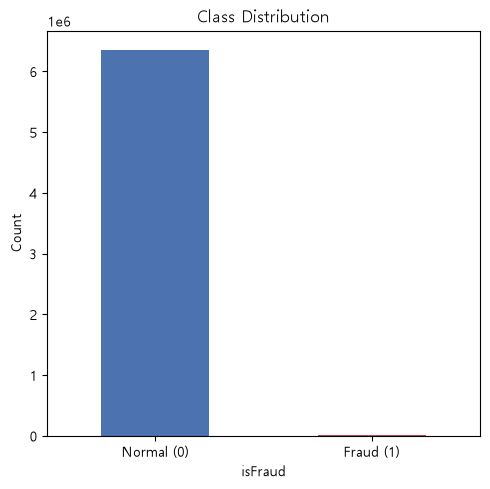

In [19]:
if DATA_AVAILABLE:
    fig, ax = plt.subplots(figsize=(5, 5))
    class_counts.plot(kind="bar", color=["#4C72B0", "#C44E52"], ax=ax)
    ax.set_xticklabels(["Normal (0)", "Fraud (1)"], rotation=0)
    ax.set_title("Class Distribution")
    ax.set_ylabel("Count")
    plt.tight_layout()
    plt.show()
else:
    print("[SKIP]")


**Accuracy만 사용하면 안 되는 이유**: 사기 비율이 0.1~1% 수준이라면, "무조건 정상(0)으로
예측"하는 모델도 Accuracy 99% 이상을 기록합니다. 하지만 이 모델은 사기 거래를 단 한 건도
잡아내지 못하므로(Recall=0) 실제로는 전혀 쓸모가 없습니다. 그래서 이 프로젝트는 Accuracy 대신
**Precision, Recall, F1, ROC-AUC, PR-AUC** 를 기준으로 모델을 평가합니다(Chapter 6 참고).


## 2-8. 거래 유형(Type)별 분석

PaySim의 거래 유형은 `CASH_IN`, `CASH_OUT`, `DEBIT`, `PAYMENT`, `TRANSFER` 5가지입니다.
PaySim 데이터셋에 대해 공개적으로 알려진 특징 중 하나는 **사기 거래가 `TRANSFER`와 `CASH_OUT`
유형에서만 발생한다**는 점입니다(계좌 이체 후 현금으로 인출하는 전형적인 자금 세탁 패턴과
일치합니다). 아래 코드로 실제 데이터에서도 이 특징이 나타나는지 직접 확인합니다.


In [20]:
if DATA_AVAILABLE:
    type_counts = df["type"].value_counts()
    print("거래 유형별 건수:")
    print(type_counts)

    fraud_by_type = df.groupby("type", observed=True)["isFraud"].agg(["sum", "count"])
    fraud_by_type.columns = ["fraud_count", "total_count"]
    fraud_by_type["fraud_ratio_percent"] = (
        fraud_by_type["fraud_count"] / fraud_by_type["total_count"] * 100
    ).round(4)
    fraud_by_type = fraud_by_type.sort_values("fraud_ratio_percent", ascending=False)

    print("\n거래 유형별 사기 건수/비율:")
    display(fraud_by_type)
else:
    print("[SKIP]")


거래 유형별 건수:
type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64

거래 유형별 사기 건수/비율:


,fraud_count,total_count,fraud_ratio_percent
type,,,
TRANSFER,4097,532909,0.7688
CASH_OUT,4116,2237500,0.1840
CASH_IN,0,1399284,0.0000
DEBIT,0,41432,0.0000
PAYMENT,0,2151495,0.0000


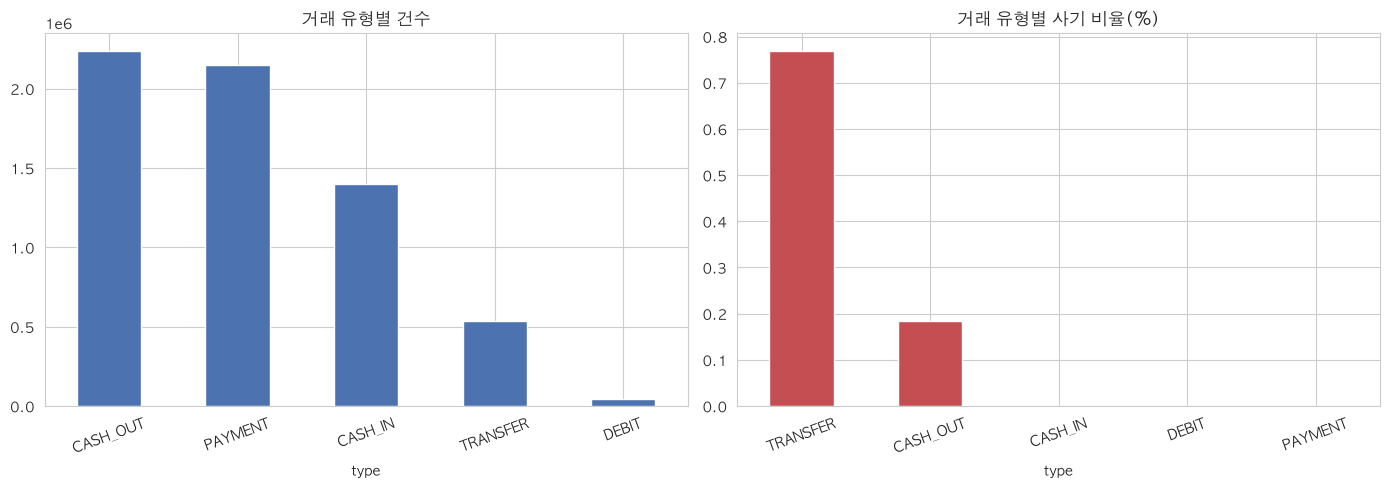

In [86]:
if DATA_AVAILABLE:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    type_counts.plot(kind="bar", color="#4C72B0", ax=axes[0])
    axes[0].set_title("거래 유형별 건수")
    axes[0].tick_params(axis="x", rotation=20)

    fraud_by_type["fraud_ratio_percent"].plot(kind="bar", color="#C44E52", ax=axes[1])
    axes[1].set_title("거래 유형별 사기 비율(%)")
    axes[1].tick_params(axis="x", rotation=20)

    plt.tight_layout()
    plt.show()
else:
    print("[SKIP]")


## 2-9. 거래 금액(Amount) 분석

정상 거래와 사기 거래의 금액 분포를 비교합니다. 금액처럼 왜도(Skewness)가 큰 변수는 로그 변환
후 분포를 다시 확인하는 것이 일반적입니다.


In [21]:
if DATA_AVAILABLE:
    print("전체 Amount 분포:")
    display(df["amount"].describe())

    print("\n정상 거래 Amount 분포:")
    display(df.loc[df["isFraud"] == 0, "amount"].describe())

    print("\n사기 거래 Amount 분포:")
    display(df.loc[df["isFraud"] == 1, "amount"].describe())
else:
    print("[SKIP]")


전체 Amount 분포:


count    6.362620e+06
mean     1.798619e+05
std      5.991358e+05
min      0.000000e+00
25%      1.338957e+04
50%      7.487194e+04
75%      2.087215e+05
max      9.244552e+07
Name: amount, dtype: float64


정상 거래 Amount 분포:


count    6.354407e+06
mean     1.781970e+05
std      5.915250e+05
min      1.000000e-02
25%      1.336840e+04
50%      7.468472e+04
75%      2.083648e+05
max      9.244552e+07
Name: amount, dtype: float64


사기 거래 Amount 분포:


count    8.213000e+03
mean     1.467967e+06
std      2.404254e+06
min      0.000000e+00
25%      1.270913e+05
50%      4.414234e+05
75%      1.517772e+06
max      1.000000e+07
Name: amount, dtype: float64

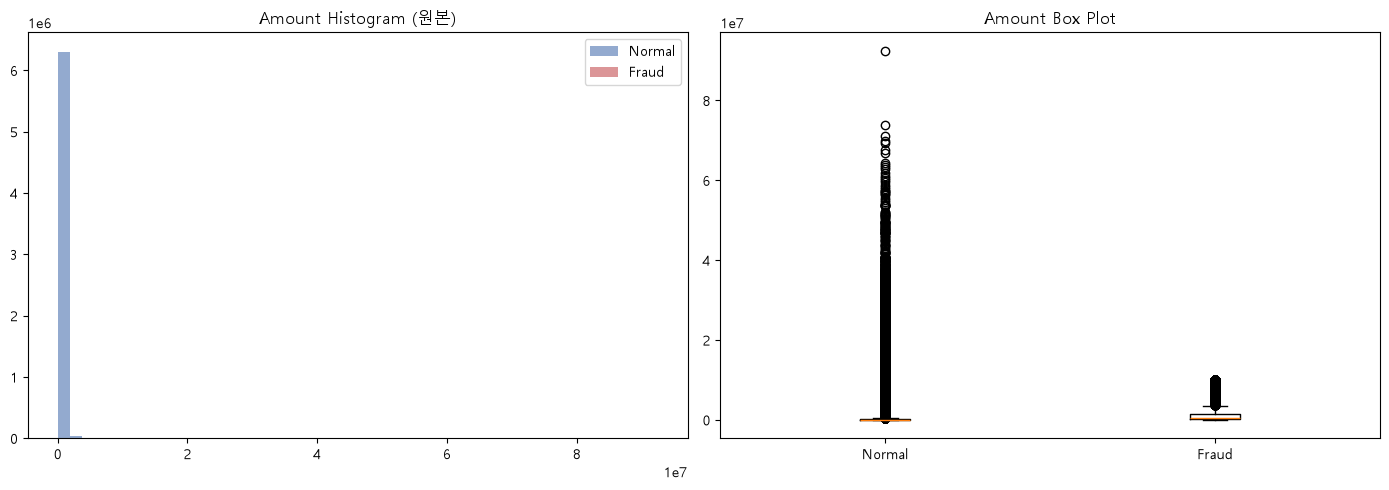

In [22]:
if DATA_AVAILABLE:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].hist(df.loc[df["isFraud"] == 0, "amount"], bins=50, alpha=0.6, label="Normal", color="#4C72B0")
    axes[0].hist(df.loc[df["isFraud"] == 1, "amount"], bins=50, alpha=0.6, label="Fraud", color="#C44E52")
    axes[0].set_title("Amount Histogram (원본)")
    axes[0].legend()

    axes[1].boxplot(
        [df.loc[df["isFraud"] == 0, "amount"], df.loc[df["isFraud"] == 1, "amount"]],
        tick_labels=["Normal", "Fraud"],
    )
    axes[1].set_title("Amount Box Plot")

    plt.tight_layout()
    plt.show()
else:
    print("[SKIP]")


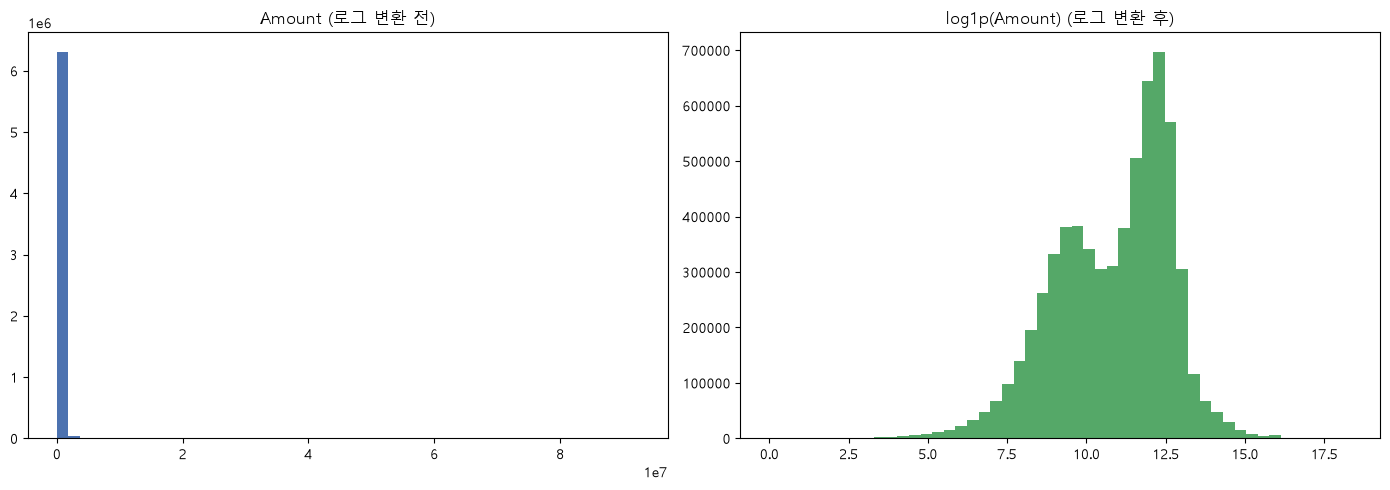

원본 Amount 왜도(Skewness): 30.994
log1p(Amount) 왜도(Skewness): -0.555


In [23]:
if DATA_AVAILABLE:
    amount_log = np.log1p(df["amount"])

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].hist(df["amount"], bins=50, color="#4C72B0")
    axes[0].set_title("Amount (로그 변환 전)")

    axes[1].hist(amount_log, bins=50, color="#55A868")
    axes[1].set_title("log1p(Amount) (로그 변환 후)")

    plt.tight_layout()
    plt.show()

    print("원본 Amount 왜도(Skewness):", round(df["amount"].skew(), 4))
    print("log1p(Amount) 왜도(Skewness):", round(amount_log.skew(), 4))
else:
    print("[SKIP]")


## 2-10. 잔액(Balance) 분석

`oldbalanceOrg`(송금자 거래 전 잔액), `oldbalanceDest`(수취인 거래 전 잔액)와 거래 금액의 관계를
살펴봅니다. `newbalanceOrig`, `newbalanceDest`(거래 **후** 잔액)는 예측 시점에 알 수 없는
정보이므로 Feature로는 사용하지 않지만, "사기 거래가 잔액을 어떻게 바꾸는지" 이해하기 위해
EDA에서는 참고합니다.


In [24]:
if DATA_AVAILABLE:
    print("oldbalanceOrg 분포:")
    display(df["oldbalanceOrg"].describe())

    print("\noldbalanceDest 분포:")
    display(df["oldbalanceDest"].describe())
else:
    print("[SKIP]")


oldbalanceOrg 분포:


count    6.362620e+06
mean     8.338831e+05
std      2.831753e+06
min      0.000000e+00
25%      0.000000e+00
50%      1.420800e+04
75%      1.073152e+05
max      5.958504e+07
Name: oldbalanceOrg, dtype: float64


oldbalanceDest 분포:


count    6.362620e+06
mean     1.100702e+06
std      3.369338e+06
min      0.000000e+00
25%      0.000000e+00
50%      1.327057e+05
75%      9.430367e+05
max      3.560159e+08
Name: oldbalanceDest, dtype: float64

In [25]:
if DATA_AVAILABLE:
    safe_sender_balance = df["oldbalanceOrg"].clip(lower=0) + 1
    safe_receiver_balance = df["oldbalanceDest"].clip(lower=0) + 1

    amount_to_sender = (df["amount"] / safe_sender_balance).replace([np.inf, -np.inf], 0)
    amount_to_receiver = (df["amount"] / safe_receiver_balance).replace([np.inf, -np.inf], 0)

    print("거래 금액 / 송금자 잔액 비율 - 정상:", round(amount_to_sender[df["isFraud"] == 0].mean(), 4))
    print("거래 금액 / 송금자 잔액 비율 - 사기:", round(amount_to_sender[df["isFraud"] == 1].mean(), 4))
    print("거래 금액 / 수취인 잔액 비율 - 정상:", round(amount_to_receiver[df["isFraud"] == 0].mean(), 4))
    print("거래 금액 / 수취인 잔액 비율 - 사기:", round(amount_to_receiver[df["isFraud"] == 1].mean(), 4))

    zero_sender_balance = (df["oldbalanceOrg"] == 0).sum()
    zero_receiver_balance = (df["oldbalanceDest"] == 0).sum()
    print("\n송금자 거래 전 잔액이 0인 거래:", zero_sender_balance)
    print("수취인 거래 전 잔액이 0인 거래:", zero_receiver_balance)

    fraud_rate_zero_receiver = df.loc[df["oldbalanceDest"] == 0, "isFraud"].mean() * 100
    fraud_rate_nonzero_receiver = df.loc[df["oldbalanceDest"] != 0, "isFraud"].mean() * 100
    print(f"수취인 잔액=0 인 경우 사기 비율: {fraud_rate_zero_receiver:.4f}%")
    print(f"수취인 잔액!=0 인 경우 사기 비율: {fraud_rate_nonzero_receiver:.4f}%")
else:
    print("[SKIP]")


거래 금액 / 송금자 잔액 비율 - 정상: 70764.32
거래 금액 / 송금자 잔액 비율 - 사기: 1161.9667
거래 금액 / 수취인 잔액 비율 - 정상: 26666.307
거래 금액 / 수취인 잔액 비율 - 사기: 969883.56

송금자 거래 전 잔액이 0인 거래: 2102449
수취인 거래 전 잔액이 0인 거래: 2704388
수취인 잔액=0 인 경우 사기 비율: 0.1979%
수취인 잔액!=0 인 경우 사기 비율: 0.0782%


## 2-11. 시간대(Hour)별 패턴 분석

`step`은 시뮬레이션 시작부터 몇 시간이 지났는지를 나타냅니다(1 step = 1시간). 하루 24시간 중
몇 시에 거래가 발생했는지(`Hour`)를 계산해서 시간대별 패턴을 확인합니다. `hour`는 0~23 사이의
숫자이지만, 막대그래프보다 시간대별 사기 비율은 **선 그래프(Line Plot)** 로 그리면 하루 동안의
흐름을 더 직관적으로 볼 수 있습니다.


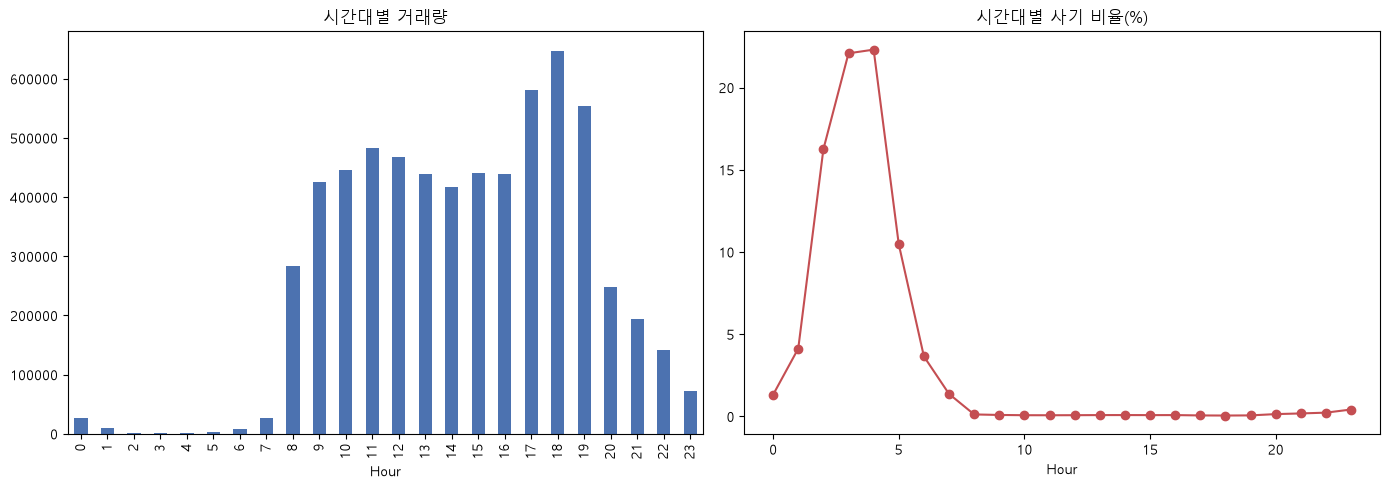

시간대별 사기 비율:
Hour
0      1.3205
1      4.1251
2     16.2431
3     22.0790
4     22.3035
5     10.4678
6      3.6493
7      1.3673
8      0.1203
9      0.0881
10     0.0726
11     0.0701
12     0.0739
13     0.0803
14     0.0818
15     0.0781
16     0.0802
17     0.0591
18     0.0528
19     0.0614
20     0.1400
21     0.1804
22     0.2287
23     0.4191
Name: isFraud, dtype: float64


In [26]:
if DATA_AVAILABLE:
    # step=1을 하루의 시작(0시)으로 보고, 하루 중 시간(0~23)을 계산한다.
    # main.py, train_model.py와 완전히 동일한 규칙을 그대로 재사용한다.
    df["Hour"] = ((df["step"].astype(int) - 1) % 24).astype(int)

    hourly_count = df.groupby("Hour").size()
    hourly_fraud_ratio = df.groupby("Hour")["isFraud"].mean() * 100

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    hourly_count.plot(kind="bar", color="#4C72B0", ax=axes[0])
    axes[0].set_title("시간대별 거래량")
    axes[0].set_xlabel("Hour")

    hourly_fraud_ratio.plot(kind="line", marker="o", color="#C44E52", ax=axes[1])
    axes[1].set_title("시간대별 사기 비율(%)")
    axes[1].set_xlabel("Hour")

    plt.tight_layout()
    plt.show()

    print("시간대별 사기 비율:")
    print(hourly_fraud_ratio.round(4))
else:
    print("[SKIP]")


## 2-12. 상관관계(Correlation) 분석

숫자형 변수들과 `isFraud` 사이의 **피어슨 상관계수(Pearson Correlation Coefficient)** 를
계산합니다. 상관계수는 -1 ~ 1 사이의 값을 가지며,

- **1에 가까울수록** 강한 양의 상관관계 (하나가 커지면 다른 하나도 커짐)
- **-1에 가까울수록** 강한 음의 상관관계 (하나가 커지면 다른 하나는 작아짐)
- **0에 가까울수록** 선형적인 관계가 거의 없음


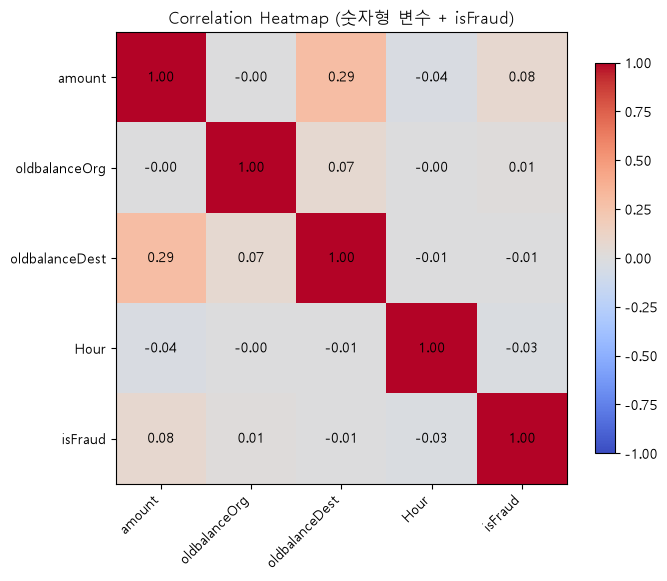

isFraud와의 상관계수 (내림차순):
isFraud           1.0000
amount            0.0767
oldbalanceOrg     0.0102
oldbalanceDest   -0.0059
Hour             -0.0278
Name: isFraud, dtype: float64


In [29]:
if DATA_AVAILABLE:
    corr_columns = ["amount", "oldbalanceOrg", "oldbalanceDest", "Hour", "isFraud"]
    corr_matrix = df[corr_columns].corr()

    fig, ax = plt.subplots(figsize=(7, 6))
    im = ax.imshow(corr_matrix, cmap="coolwarm", vmin=-1, vmax=1)
    ax.set_xticks(range(len(corr_columns)))
    ax.set_yticks(range(len(corr_columns)))
    ax.set_xticklabels(corr_columns, rotation=45, ha="right")
    ax.set_yticklabels(corr_columns)
    for i in range(len(corr_columns)):
        for j in range(len(corr_columns)):
            ax.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}", ha="center", va="center", color="black")
    fig.colorbar(im, ax=ax, shrink=0.8)
    ax.set_title("Correlation Heatmap (숫자형 변수 + isFraud)")
    plt.tight_layout()
    plt.show()

    print("isFraud와의 상관계수 (내림차순):")
    print(corr_matrix["isFraud"].sort_values(ascending=False).round(4))
else:
    print("[SKIP]")


## 2-13. Box Plot - 이상치(Outlier) 분석

Box Plot(상자 그림)은 데이터의 분포를 다음 5가지 값으로 요약해서 보여줍니다.

```text
최솟값(이상치 제외) ─ 1사분위수(Q1) ─ 중앙값(Median) ─ 3사분위수(Q3) ─ 최댓값(이상치 제외)
```

Q1과 Q3 사이의 거리를 **IQR(사분위 범위, Interquartile Range)** 이라고 하며, 일반적으로
`Q1 - 1.5*IQR` 보다 작거나 `Q3 + 1.5*IQR` 보다 큰 값을 통계적 이상치로 봅니다.


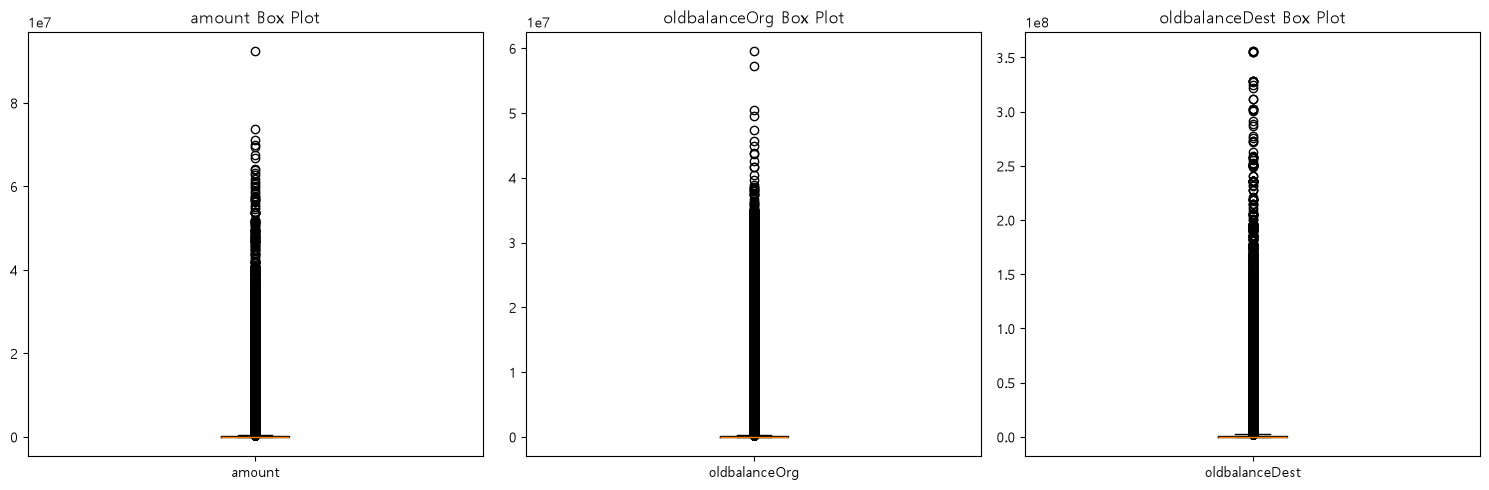

IQR 기준 컬럼별 이상치 개수:
  amount : 338,078건 (5.31%)
  oldbalanceOrg : 1,112,507건 (17.49%)
  oldbalanceDest : 786,135건 (12.36%)


In [32]:
if DATA_AVAILABLE:
    outlier_columns = ["amount", "oldbalanceOrg", "oldbalanceDest"]

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    outlier_summary = {}
    for i, col in enumerate(outlier_columns):
        axes[i].boxplot(df[col], tick_labels=[col])
        axes[i].set_title(f"{col} Box Plot")

        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        outlier_count = ((df[col] < lower) | (df[col] > upper)).sum()
        outlier_summary[col] = outlier_count

    plt.tight_layout()
    plt.show()

    print("IQR 기준 컬럼별 이상치 개수:")
    for col, cnt in outlier_summary.items():
        print(f"  {col} : {cnt:,}건 ({cnt / len(df) * 100:.2f}%)")
else:
    print("[SKIP]")


**주의**: `amount`, `oldbalanceOrg`, `oldbalanceDest`는 원래 왜도가 매우 큰(대부분 작고
가끔 매우 큰) 분포이므로, IQR 기준 "이상치"가 실제로는 데이터 오류가 아니라 정상적으로 발생하는
고액 거래인 경우가 많습니다. 따라서 이 값들을 무조건 제거하지 않고, Chapter 4에서
`IsLargeTransaction`처럼 "고액 거래 여부"를 나타내는 파생변수로 활용합니다.


## 2-14. EDA 핵심 발견 사항(EDA Findings)

지금까지의 EDA 결과를 근거와 함께 정리합니다. 아래 결과는 위 셀에서 실제로 계산한 값을 그대로
사용해 자동으로 생성됩니다(하드코딩된 수치가 아닙니다).


In [ ]:
if DATA_AVAILABLE:
    top_type = fraud_by_type.index[0]
    top_type_ratio = fraud_by_type.loc[top_type, "fraud_ratio_percent"]
    peak_fraud_hour = hourly_fraud_ratio.idxmax()
    peak_fraud_hour_ratio = hourly_fraud_ratio.max()
    amount_corr = corr_matrix.loc["amount", "isFraud"]

    findings = f"""
**Finding 1. 클래스가 극단적으로 불균형하다.**
근거: 전체 {len(df):,}건 중 사기 거래는 {fraud_count:,}건으로 전체의 {fraud_ratio:.4f}%에 불과하다.
해석: Accuracy만으로 모델을 평가하면 "전부 정상"으로 예측하는 무의미한 모델도 높은 점수를
받으므로, Precision/Recall/F1/PR-AUC를 함께 봐야 한다(Chapter 6).

**Finding 2. 거래 유형(Type)에 따라 사기 비율 차이가 크다.**
근거: `{top_type}` 유형의 사기 비율이 {top_type_ratio:.4f}%로 가장 높다.
해석: 거래 유형은 사기 여부를 구분하는 강력한 신호이며, `IsTransfer`/`IsCashOut` 파생변수의
근거가 된다(Chapter 4).

**Finding 3. 거래 금액과 사기 여부의 선형 상관관계는 크지 않다.**
근거: `amount`와 `isFraud`의 피어슨 상관계수는 {amount_corr:.4f}이다.
해석: 단순 선형 상관관계는 약하더라도, "잔액 대비 금액 비율"처럼 다른 변수와 결합했을 때
더 강한 신호가 될 수 있다(Chapter 4 `AmountToSenderBalance` 참고).

**Finding 4. 송금자/수취인 잔액 패턴이 사기와 관련이 있을 수 있다.**
근거: 수취인 잔액이 0인 거래의 사기 비율은 {fraud_rate_zero_receiver:.4f}%, 0이 아닌 거래는
{fraud_rate_nonzero_receiver:.4f}%이다.
해석: 이 차이가 클수록 `IsSenderBalanceZero`처럼 잔액 기반 파생변수가 유용하다는 근거가 된다.

**Finding 5. 시간대(Hour)에 따라 사기 비율이 달라진다.**
근거: {peak_fraud_hour}시의 사기 비율이 {peak_fraud_hour_ratio:.4f}%로 가장 높다.
해석: 시간대 정보(`Hour`, `TimeOfDay`)가 위험 신호로 활용될 수 있다.

**Finding 6. `amount`, `oldbalanceOrg`, `oldbalanceDest`는 왜도가 크고 IQR 기준 이상치가
많다.**
해석: 이런 변수는 그대로 쓰기보다 로그 변환(`AmountLog`)이나 "고액 거래 여부"(`IsLargeTransaction`)
처럼 다루기 쉬운 형태로 정리하는 것이 유용하다.
"""
    display(Markdown(findings))
else:
    print("[SKIP] 데이터가 없어 EDA 핵심 발견 사항을 생성할 수 없습니다.")
    print("data/ 폴더에 PaySim 데이터를 추가한 뒤 이 노트북을 처음부터 다시 실행하세요.")


In [33]:
display(df.head())

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,Hour
0,1,PAYMENT,9839.639648,C1231006815,170136.0,160296.359375,M1979787155,0.0,0.0,0,0,0
1,1,PAYMENT,1864.280029,C1666544295,21249.0,19384.720703,M2044282225,0.0,0.0,0,0,0
2,1,TRANSFER,181.000000,C1305486145,181.0,0.000000,C553264065,0.0,0.0,1,0,0
3,1,CASH_OUT,181.000000,C840083671,181.0,0.000000,C38997010,21182.0,0.0,1,0,0
4,1,PAYMENT,11668.139648,C2048537720,41554.0,29885.859375,M1230701703,0.0,0.0,0,0,0



# Chapter 3. Hypothesis (가설 수립)

**가설 1.** 사기 거래는 `TRANSFER`, `CASH_OUT` 유형에 집중되어 나타날 것이다.
-> Chapter 2-8에서 확인한 유형별 사기 비율을 근거로, Chapter 4에서 `IsTransfer`/`IsCashOut`
파생변수로 직접 검증한다.

**가설 2.** 거래 금액이 송금자 잔액에서 차지하는 비율이 높을수록 사기 가능성이 높을 것이다.
-> Chapter 2-10에서 확인한 잔액 패턴을 근거로, Chapter 4에서 `AmountToSenderBalance`로 직접
검증한다.

**가설 3.** 거래 후 송금자의 예상 잔액이 0에 가까울수록(계좌를 거의 비움) 사기 가능성이 높을
것이다. -> Chapter 4에서 `IsSenderBalanceZero`로 직접 검증한다.

**가설 4.** 수취인의 거래 전 잔액이 매우 낮은(빈 계좌에 가까운) 거래일수록 사기 가능성이 높을
것이다. -> Chapter 2-10의 결과를 근거로, Chapter 4에서 직접 검증한다.

**가설 5.** 특정 시간대(예: 심야)에 사기 비율이 더 높게 나타날 것이다. -> Chapter 2-11의 결과를
근거로, Chapter 4에서 `Hour`/`TimeOfDay`로 직접 검증한다.

**가설 6.** 거래 금액 자체가 매우 큰(고액) 거래일수록 사기 가능성이 높을 것이다. -> Chapter 4에서
`IsLargeTransaction`으로 직접 검증한다.

**가설 7.** 금액을 로그 변환(`AmountLog`)하면 원본 금액보다 모델이 더 안정적으로 학습할 것이다.
-> Chapter 2-9에서 확인한 왜도(Skewness) 감소를 근거로, Chapter 4에서 직접 검증한다.


이제 이 가설들을 실제 파생변수(Feature)로 만드는 **Feature Engineering** 을 시작합니다.



# Chapter 4. Feature Engineering (파생변수 생성)


Feature Engineering은 원본 컬럼을 조합하거나 가공하여, 모델이 사기 패턴을 더 쉽게 학습할 수
있는 새로운 입력값을 만드는 과정입니다. 이번 Chapter에서는 아래 8개의 Feature 블록으로
`feature_engineering.py`의 `FraudFeatureEngineer`가 생성하는 11개 파생변수를 하나씩 직접
만들어보고 효과를 확인합니다.

```text
1. TimeOfDay                                       - 시간대 구간화
2. AmountLog                                        - 거래 금액 로그 변환
3. AmountToSenderBalance / AmountToReceiverBalance  - 거래금액 대비 잔액 비율
4. SenderBalanceAfterEstimated / ReceiverBalanceAfterEstimated - 거래 후 예상 잔액
5. IsSenderBalanceZero                              - 송금자 잔액 소진 여부
6. IsLargeTransaction                               - 고액 거래 여부
7. IsTransfer / IsCashOut                           - 고위험 거래 유형 여부
8. BalanceDifference                                - 송금자-수취인 잔액 차이
```

파생변수를 만들 때는 다음 원칙을 지킵니다.

```text
1. 비즈니스 의미가 있어야 한다.
2. 원본 변수보다 이해하기 쉬운 정보를 제공해야 한다.
3. 예측 시점(거래가 실행되기 전)에 계산할 수 있어야 한다.
4. Target(isFraud)을 직접 사용하지 않는다.
5. 데이터 누수(Data Leakage)가 없어야 한다.
```

> **참고**: 실제 서비스 API(`main.py`)는 `type, amount, oldbalanceOrg, oldbalanceDest, Hour`
> 5개만 입력으로 받습니다. `newbalanceOrig`, `newbalanceDest`(거래 후 잔액), `nameOrig`,
> `nameDest`(고객 식별자), `isFlaggedFraud`(기존 탐지 결과)는 원칙 3·5에 위배되므로 이번
> Feature Engineering에서 사용하지 않습니다.

## 성능 비교를 위한 준비

각 Feature를 만들 때마다 "이 Feature를 추가하기 전 vs 추가한 후" 모델 성능을 비교합니다.
회귀 문제와 달리 이번에는 분류 문제이므로 **Precision, Recall, F1, PR-AUC** 로 성능을
비교합니다. 클래스 불균형이 매우 심하므로(Chapter 2-7) Accuracy는 비교 기준으로 사용하지
않습니다.


In [34]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score, recall_score, f1_score, average_precision_score

# Target, 식별자, 데이터 누수 컬럼은 Feature 실험에서 제외합니다.
FE_BASELINE_COLUMNS = ["type", "amount", "oldbalanceOrg", "oldbalanceDest", "Hour"]

print("Baseline Feature:", FE_BASELINE_COLUMNS)


def quick_evaluate(frame, feature_cols, label):
    """주어진 Feature 목록으로 RandomForest Classifier를 빠르게 학습하고 성능을 반환한다.
    (Feature Engineering 실습용 - Chapter 6의 공식 Pipeline과는 별개)
    """
    X = pd.get_dummies(frame[feature_cols], drop_first=False)
    y = frame["isFraud"]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
    )

    # max_samples: 트리마다 학습 데이터 일부(30%)만 부트스트랩해 대용량 데이터에서도 빠르게 학습한다.
    model = RandomForestClassifier(
        n_estimators=200, max_depth=16, max_samples=0.3,
        class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1
    )
    model.fit(X_train, y_train)
    proba = model.predict_proba(X_test)[:, 1]
    pred = (proba >= 0.5).astype(int)

    return {
        "Model": label,
        "Precision": round(precision_score(y_test, pred, zero_division=0), 4),
        "Recall": round(recall_score(y_test, pred, zero_division=0), 4),
        "F1": round(f1_score(y_test, pred, zero_division=0), 4),
        "PR-AUC": round(average_precision_score(y_test, proba), 4),
    }


if DATA_AVAILABLE:
    baseline_result = quick_evaluate(df, FE_BASELINE_COLUMNS, "Baseline (원본 Feature)")
    feature_experiment_results = [baseline_result]
    display(pd.DataFrame(feature_experiment_results))
else:
    feature_experiment_results = []
    print("[SKIP]")


Baseline Feature: ['type', 'amount', 'oldbalanceOrg', 'oldbalanceDest', 'Hour']


,Model,Precision,Recall,F1,PR-AUC
0,Baseline (원본 Feature),0.0683,0.9854,0.1277,0.8654


## Feature 1. TimeOfDay (시간대 구간화)

`Hour`는 0~23 사이의 연속된 숫자입니다. EDA(2-11, 가설 5)에서 확인했듯, 특정 시간대에 사기
비율이 높아지는 패턴이 있을 수 있습니다. 이를 새벽/오전/오후/저녁 4개 구간으로 단순화합니다.

### 생성 이유
가설 5를 직접 검증하고, 트리 계열 모델이 시간대 패턴을 더 쉽게 분기하도록 돕습니다.


In [35]:
if DATA_AVAILABLE:
    hour_bins = [-1, 5, 11, 17, 23]
    hour_labels = ["Dawn(0-5)", "Morning(6-11)", "Afternoon(12-17)", "Evening(18-23)"]

    df["TimeOfDay"] = pd.cut(df["Hour"], bins=hour_bins, labels=hour_labels).astype(str)

    time_of_day_effect = df.groupby("TimeOfDay")["isFraud"].agg(["mean", "count"])
    time_of_day_effect.columns = ["fraud_rate", "count"]
    time_of_day_effect["fraud_rate"] = (time_of_day_effect["fraud_rate"] * 100).round(4)
    display(time_of_day_effect)
else:
    print("[SKIP]")


,fraud_rate,count
TimeOfDay,,
Afternoon(12-17),0.0747,2786875
Dawn(0-5),4.6222,44438
Evening(18-23),0.1079,1856747
Morning(6-11),0.1239,1674560


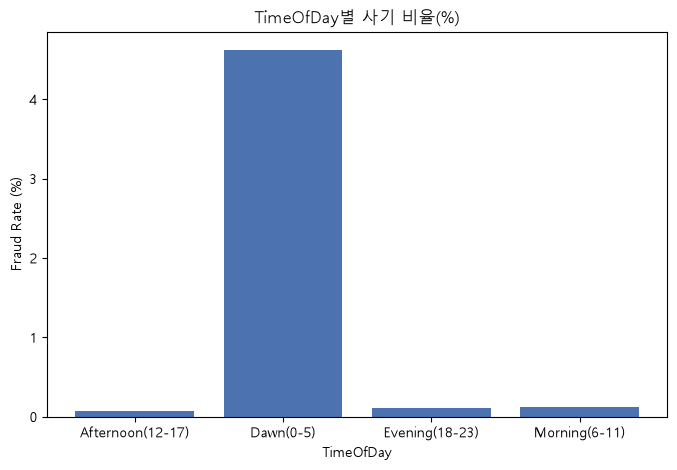

In [36]:
if DATA_AVAILABLE:
    plt.figure(figsize=(8, 5))
    plt.bar(time_of_day_effect.index, time_of_day_effect["fraud_rate"], color="#4C72B0")
    plt.title("TimeOfDay별 사기 비율(%)")
    plt.xlabel("TimeOfDay")
    plt.ylabel("Fraud Rate (%)")
    plt.show()
else:
    print("[SKIP]")


In [37]:
if DATA_AVAILABLE:
    result = quick_evaluate(df, FE_BASELINE_COLUMNS + ["TimeOfDay"], "Baseline + TimeOfDay")
    feature_experiment_results.append(result)
    display(pd.DataFrame(feature_experiment_results))
else:
    print("[SKIP]")


,Model,Precision,Recall,F1,PR-AUC
0,Baseline (원본 Feature),0.0683,0.9854,0.1277,0.8654
1,Baseline + TimeOfDay,0.0771,0.9629,0.1429,0.8346


## Feature 2. AmountLog (거래 금액 로그 변환)

2-9에서 확인했듯 `amount`는 왜도(Skewness)가 매우 큰 분포입니다. `log1p()`로 로그 변환하면
분포가 대칭에 가까워져 선형 계열 모델(Logistic Regression)이 더 안정적으로 학습할 수 있습니다.

### 생성 이유
가설 7을 직접 검증합니다.


In [38]:
if DATA_AVAILABLE:
    df["AmountLog"] = np.log1p(df["amount"])

    print("AmountLog와 isFraud의 상관계수:", round(df["AmountLog"].corr(df["isFraud"]), 4))
    print("amount와 isFraud의 상관계수    :", round(df["amount"].corr(df["isFraud"]), 4))
    display(df[["amount", "AmountLog"]].describe())
else:
    print("[SKIP]")


AmountLog와 isFraud의 상관계수: 0.0406
amount와 isFraud의 상관계수    : 0.0767


,amount,AmountLog
count,6.362620e+06,6.362620e+06
mean,1.798619e+05,1.084087e+01
std,5.991358e+05,1.810255e+00
min,0.000000e+00,0.000000e+00
25%,1.338957e+04,9.502306e+00
50%,7.487194e+04,1.122355e+01
75%,2.087215e+05,1.224876e+01
max,9.244552e+07,1.834213e+01


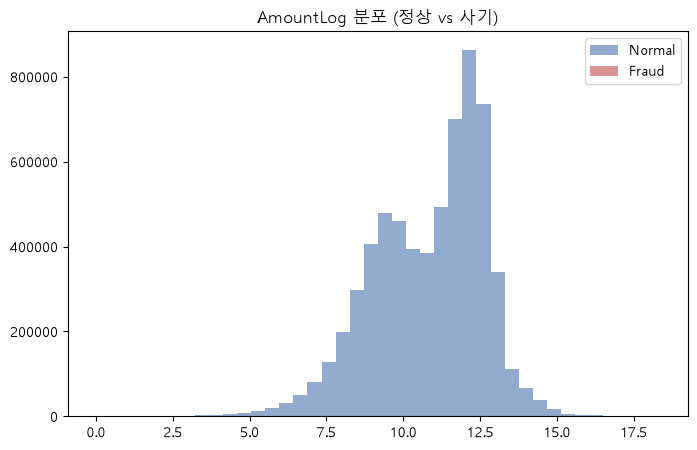

In [39]:
if DATA_AVAILABLE:
    plt.figure(figsize=(8, 5))
    plt.hist(df.loc[df["isFraud"] == 0, "AmountLog"], bins=40, alpha=0.6, label="Normal", color="#4C72B0")
    plt.hist(df.loc[df["isFraud"] == 1, "AmountLog"], bins=40, alpha=0.6, label="Fraud", color="#C44E52")
    plt.title("AmountLog 분포 (정상 vs 사기)")
    plt.legend()
    plt.show()
else:
    print("[SKIP]")


In [40]:
if DATA_AVAILABLE:
    result = quick_evaluate(df, FE_BASELINE_COLUMNS + ["AmountLog"], "Baseline + AmountLog")
    feature_experiment_results.append(result)
    display(pd.DataFrame(feature_experiment_results))
else:
    print("[SKIP]")


,Model,Precision,Recall,F1,PR-AUC
0,Baseline (원본 Feature),0.0683,0.9854,0.1277,0.8654
1,Baseline + TimeOfDay,0.0771,0.9629,0.1429,0.8346
2,Baseline + AmountLog,0.0717,0.9890,0.1337,0.8756


> **모델에 따라 Feature의 가치가 다르게 나타날 수 있습니다.** RandomForest는 이미 비선형
> 분기를 스스로 학습할 수 있어 `AmountLog` 추가 효과가 크지 않을 수 있습니다. 반면 Chapter 6의
> Logistic Regression처럼 선형 관계를 가정하는 모델에서는 왜도를 줄인 `AmountLog`가 훨씬 더
> 큰 도움이 될 수 있습니다. 즉 "이 Feature가 좋은가?"는 어떤 모델을 쓰느냐에 따라 달라질 수
> 있습니다.


## Feature 3. AmountToSenderBalance / AmountToReceiverBalance (거래금액 대비 잔액 비율)

거래 금액이 송금자/수취인 잔액에서 차지하는 비율을 계산합니다. 분모가 0이어도 `NaN`/`Infinity`가
발생하지 않도록 분모에 +1을 더해 안전하게 계산합니다.

### 생성 이유
가설 2를 직접 검증합니다.


In [41]:
if DATA_AVAILABLE:
    safe_sender = df["oldbalanceOrg"].clip(lower=0) + 1
    safe_receiver = df["oldbalanceDest"].clip(lower=0) + 1

    df["AmountToSenderBalance"] = (df["amount"] / safe_sender).replace([np.inf, -np.inf], 0)
    df["AmountToReceiverBalance"] = (df["amount"] / safe_receiver).replace([np.inf, -np.inf], 0)

    for col in ["AmountToSenderBalance", "AmountToReceiverBalance"]:
        print(f"{col} 평균 - 정상: {df.loc[df['isFraud'] == 0, col].mean():.4f}  "
              f"사기: {df.loc[df['isFraud'] == 1, col].mean():.4f}")
else:
    print("[SKIP]")


AmountToSenderBalance 평균 - 정상: 70764.3203  사기: 1161.9667
AmountToReceiverBalance 평균 - 정상: 26666.3066  사기: 969883.5000


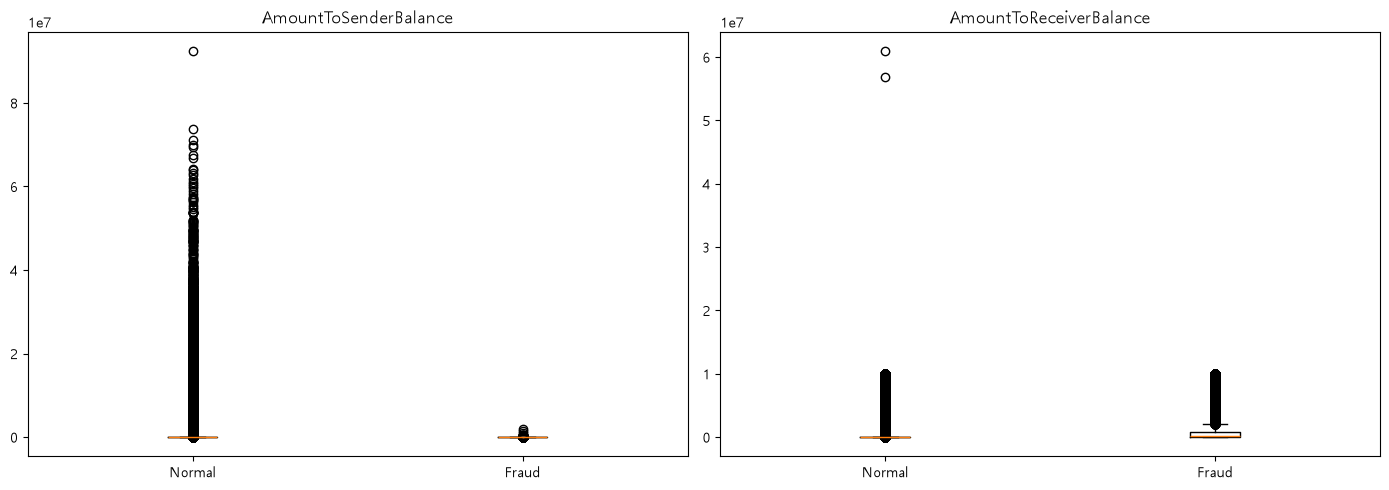

In [42]:
if DATA_AVAILABLE:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].boxplot(
        [df.loc[df["isFraud"] == 0, "AmountToSenderBalance"], df.loc[df["isFraud"] == 1, "AmountToSenderBalance"]],
        tick_labels=["Normal", "Fraud"],
    )
    axes[0].set_title("AmountToSenderBalance")

    axes[1].boxplot(
        [df.loc[df["isFraud"] == 0, "AmountToReceiverBalance"], df.loc[df["isFraud"] == 1, "AmountToReceiverBalance"]],
        tick_labels=["Normal", "Fraud"],
    )
    axes[1].set_title("AmountToReceiverBalance")

    plt.tight_layout()
    plt.show()
else:
    print("[SKIP]")


In [43]:
if DATA_AVAILABLE:
    cols = FE_BASELINE_COLUMNS + ["AmountToSenderBalance", "AmountToReceiverBalance"]
    result = quick_evaluate(df, cols, "Baseline + AmountToSenderBalance + AmountToReceiverBalance")
    feature_experiment_results.append(result)
    display(pd.DataFrame(feature_experiment_results))
else:
    print("[SKIP]")


,Model,Precision,Recall,F1,PR-AUC
0,Baseline (원본 Feature),0.0683,0.9854,0.1277,0.8654
1,Baseline + TimeOfDay,0.0771,0.9629,0.1429,0.8346
2,Baseline + AmountLog,0.0717,0.9890,0.1337,0.8756
3,Baseline + AmountToSenderBalance + AmountToRec...,0.9915,0.9976,0.9945,0.9984


## Feature 4. SenderBalanceAfterEstimated / ReceiverBalanceAfterEstimated (거래 후 예상 잔액)

`newbalanceOrig`, `newbalanceDest`(실제 거래 후 잔액)는 예측 시점에 알 수 없는 사후 정보라
사용할 수 없습니다. 대신 예측 시점에 알 수 있는 `oldbalanceOrg`/`oldbalanceDest`와 `amount`만으로
"거래가 그대로 처리된다면" 어떤 잔액이 될지 **추정**합니다.

### 생성 이유
가설 3을 직접 검증하며, 사후 정보 없이도 비슷한 신호를 안전하게(Data Leakage 없이) 확보합니다.


In [44]:
if DATA_AVAILABLE:
    df["SenderBalanceAfterEstimated"] = df["oldbalanceOrg"] - df["amount"]
    df["ReceiverBalanceAfterEstimated"] = df["oldbalanceDest"] + df["amount"]

    print("SenderBalanceAfterEstimated와 isFraud의 상관계수:",
          round(df["SenderBalanceAfterEstimated"].corr(df["isFraud"]), 4))
    display(df[["oldbalanceOrg", "amount", "SenderBalanceAfterEstimated"]].describe())
else:
    print("[SKIP]")


SenderBalanceAfterEstimated와 isFraud의 상관계수: -0.0058


,oldbalanceOrg,amount,SenderBalanceAfterEstimated
count,6.362620e+06,6.362620e+06,6.362620e+06
mean,8.338831e+05,1.798619e+05,6.540212e+05
std,2.831753e+06,5.991358e+05,2.901098e+06
min,0.000000e+00,0.000000e+00,-9.244552e+07
25%,0.000000e+00,1.338957e+04,-1.464904e+05
50%,1.420800e+04,7.487194e+04,-1.461912e+04
75%,1.073152e+05,2.087215e+05,4.948488e+04
max,5.958504e+07,9.244552e+07,4.958504e+07


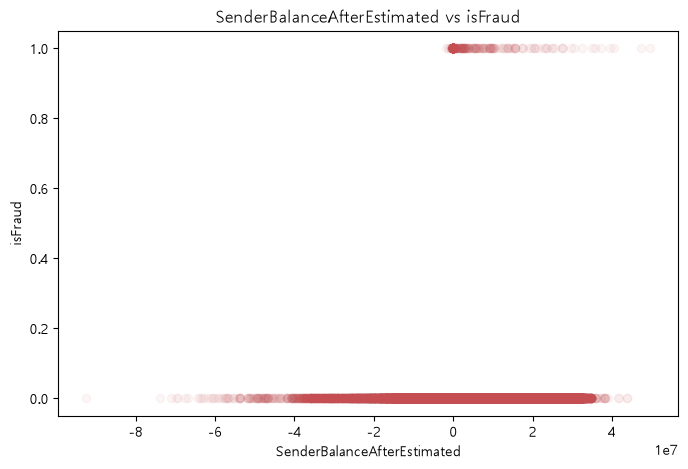

In [45]:
if DATA_AVAILABLE:
    plt.figure(figsize=(8, 5))
    plt.scatter(
        df["SenderBalanceAfterEstimated"], df["isFraud"], alpha=0.05, color="#C44E52"
    )
    plt.title("SenderBalanceAfterEstimated vs isFraud")
    plt.xlabel("SenderBalanceAfterEstimated")
    plt.ylabel("isFraud")
    plt.show()
else:
    print("[SKIP]")


In [47]:
display(df.head())

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,Hour,TimeOfDay,AmountLog,AmountToSenderBalance,AmountToReceiverBalance,SenderBalanceAfterEstimated,ReceiverBalanceAfterEstimated
0,1,PAYMENT,9839.639648,C1231006815,170136.0,160296.359375,M1979787155,0.0,0.0,0,0,0,Dawn(0-5),9.194276,0.057834,9839.639648,160296.359375,9839.639648
1,1,PAYMENT,1864.280029,C1666544295,21249.0,19384.720703,M2044282225,0.0,0.0,0,0,0,Dawn(0-5),7.531167,0.087731,1864.280029,19384.720703,1864.280029
2,1,TRANSFER,181.000000,C1305486145,181.0,0.000000,C553264065,0.0,0.0,1,0,0,Dawn(0-5),5.204007,0.994505,181.000000,0.000000,181.000000
3,1,CASH_OUT,181.000000,C840083671,181.0,0.000000,C38997010,21182.0,0.0,1,0,0,Dawn(0-5),5.204007,0.994505,0.008545,0.000000,21363.000000
4,1,PAYMENT,11668.139648,C2048537720,41554.0,29885.859375,M1230701703,0.0,0.0,0,0,0,Dawn(0-5),9.364703,0.280788,11668.139648,29885.859375,11668.139648


In [46]:
if DATA_AVAILABLE:
    cols = FE_BASELINE_COLUMNS + ["SenderBalanceAfterEstimated", "ReceiverBalanceAfterEstimated"]
    result = quick_evaluate(df, cols, "Baseline + SenderBalanceAfterEstimated + ReceiverBalanceAfterEstimated")
    feature_experiment_results.append(result)
    display(pd.DataFrame(feature_experiment_results))
else:
    print("[SKIP]")


,Model,Precision,Recall,F1,PR-AUC
0,Baseline (원본 Feature),0.0683,0.9854,0.1277,0.8654
1,Baseline + TimeOfDay,0.0771,0.9629,0.1429,0.8346
2,Baseline + AmountLog,0.0717,0.9890,0.1337,0.8756
3,Baseline + AmountToSenderBalance + AmountToRec...,0.9915,0.9976,0.9945,0.9984
4,Baseline + SenderBalanceAfterEstimated + Recei...,0.9964,0.9976,0.9970,0.9982


## Feature 5. IsSenderBalanceZero (송금자 잔액 소진 여부)

Feature 4에서 추정한 `SenderBalanceAfterEstimated`가 0 이하이면, 이 거래로 계좌를 거의 다
비운다는 뜻입니다.

### 생성 이유
계좌를 비우는 패턴은 대표적인 사기 패턴으로 알려져 있습니다(2-10 참고).


In [48]:
if DATA_AVAILABLE:
    df["IsSenderBalanceZero"] = (df["SenderBalanceAfterEstimated"] <= 0).astype(int)

    zero_effect = df.groupby("IsSenderBalanceZero")["isFraud"].agg(["mean", "count"])
    zero_effect.columns = ["fraud_rate", "count"]
    zero_effect["fraud_rate"] = (zero_effect["fraud_rate"] * 100).round(4)
    display(zero_effect)
else:
    print("[SKIP]")


,fraud_rate,count
IsSenderBalanceZero,,
0,0.0066,2275506
1,0.1973,4087114


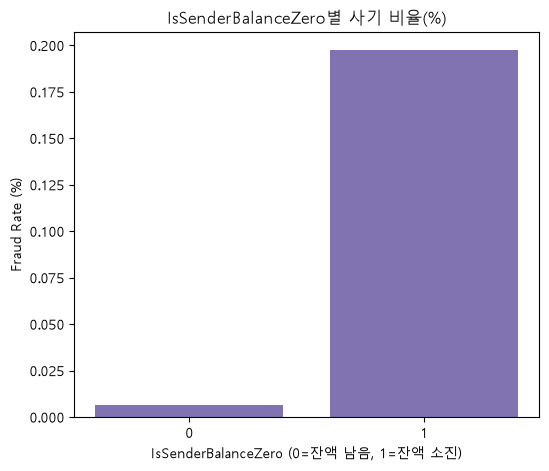

In [49]:
if DATA_AVAILABLE:
    plt.figure(figsize=(6, 5))
    plt.bar(zero_effect.index.astype(str), zero_effect["fraud_rate"], color="#8172B2")
    plt.title("IsSenderBalanceZero별 사기 비율(%)")
    plt.xlabel("IsSenderBalanceZero (0=잔액 남음, 1=잔액 소진)")
    plt.ylabel("Fraud Rate (%)")
    plt.show()
else:
    print("[SKIP]")


In [50]:
if DATA_AVAILABLE:
    result = quick_evaluate(df, FE_BASELINE_COLUMNS + ["IsSenderBalanceZero"], "Baseline + IsSenderBalanceZero")
    feature_experiment_results.append(result)
    display(pd.DataFrame(feature_experiment_results))
else:
    print("[SKIP]")


,Model,Precision,Recall,F1,PR-AUC
0,Baseline (원본 Feature),0.0683,0.9854,0.1277,0.8654
1,Baseline + TimeOfDay,0.0771,0.9629,0.1429,0.8346
2,Baseline + AmountLog,0.0717,0.9890,0.1337,0.8756
3,Baseline + AmountToSenderBalance + AmountToRec...,0.9915,0.9976,0.9945,0.9984
4,Baseline + SenderBalanceAfterEstimated + Recei...,0.9964,0.9976,0.9970,0.9982
5,Baseline + IsSenderBalanceZero,0.2381,0.9878,0.3837,0.9330


## Feature 6. IsLargeTransaction (고액 거래 여부)

2-13 이상치 분석처럼 `amount`는 대부분 작고 가끔 매우 큰 값이 나오는 분포입니다. **학습 데이터
기준 상위 5%** 를 "고액 거래"로 표시합니다. (임계값은 실제 서비스에서도 `FraudFeatureEngineer`가
학습 데이터로 동일하게 계산합니다 - `feature_engineering.py` 참고)

### 생성 이유
가설 6을 직접 검증합니다.


In [51]:
if DATA_AVAILABLE:
    large_transaction_threshold = df["amount"].quantile(0.95)
    df["IsLargeTransaction"] = (df["amount"] > large_transaction_threshold).astype(int)

    print("고액 거래 임계값(95분위):", round(large_transaction_threshold, 2))

    large_effect = df.groupby("IsLargeTransaction")["isFraud"].agg(["mean", "count"])
    large_effect.columns = ["fraud_rate", "count"]
    large_effect["fraud_rate"] = (large_effect["fraud_rate"] * 100).round(4)
    display(large_effect)
else:
    print("[SKIP]")


고액 거래 임계값(95분위): 518634.19


,fraud_rate,count
IsLargeTransaction,,
0,0.0730,6044489
1,1.1954,318131


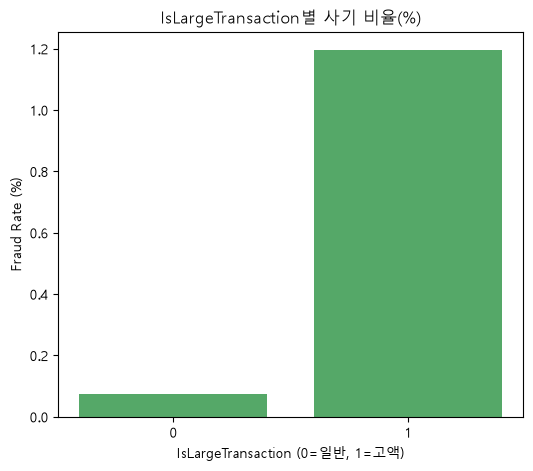

In [52]:
if DATA_AVAILABLE:
    plt.figure(figsize=(6, 5))
    plt.bar(large_effect.index.astype(str), large_effect["fraud_rate"], color="#55A868")
    plt.title("IsLargeTransaction별 사기 비율(%)")
    plt.xlabel("IsLargeTransaction (0=일반, 1=고액)")
    plt.ylabel("Fraud Rate (%)")
    plt.show()
else:
    print("[SKIP]")


In [53]:
if DATA_AVAILABLE:
    result = quick_evaluate(df, FE_BASELINE_COLUMNS + ["IsLargeTransaction"], "Baseline + IsLargeTransaction")
    feature_experiment_results.append(result)
    display(pd.DataFrame(feature_experiment_results))
else:
    print("[SKIP]")


,Model,Precision,Recall,F1,PR-AUC
0,Baseline (원본 Feature),0.0683,0.9854,0.1277,0.8654
1,Baseline + TimeOfDay,0.0771,0.9629,0.1429,0.8346
2,Baseline + AmountLog,0.0717,0.9890,0.1337,0.8756
3,Baseline + AmountToSenderBalance + AmountToRec...,0.9915,0.9976,0.9945,0.9984
4,Baseline + SenderBalanceAfterEstimated + Recei...,0.9964,0.9976,0.9970,0.9982
5,Baseline + IsSenderBalanceZero,0.2381,0.9878,0.3837,0.9330
6,Baseline + IsLargeTransaction,0.0595,0.9830,0.1123,0.8594


## Feature 7. IsTransfer / IsCashOut (고위험 거래 유형 여부)

2-8에서 확인한 거래 유형-사기 관계를 이진 신호로 명확하게 표시합니다.

### 생성 이유
가설 1을 직접 검증합니다.


In [54]:
if DATA_AVAILABLE:
    df["IsTransfer"] = (df["type"] == "TRANSFER").astype(int)
    df["IsCashOut"] = (df["type"] == "CASH_OUT").astype(int)

    for col in ["IsTransfer", "IsCashOut"]:
        effect = df.groupby(col)["isFraud"].mean() * 100
        print(f"--- {col}별 사기 비율(%) ---")
        print(effect.round(4))
        print()
else:
    print("[SKIP]")


--- IsTransfer별 사기 비율(%) ---
IsTransfer
0    0.0706
1    0.7688
Name: isFraud, dtype: float64

--- IsCashOut별 사기 비율(%) ---
IsCashOut
0    0.0993
1    0.1840
Name: isFraud, dtype: float64



In [55]:
if DATA_AVAILABLE:
    result = quick_evaluate(df, FE_BASELINE_COLUMNS + ["IsTransfer", "IsCashOut"], "Baseline + IsTransfer + IsCashOut")
    feature_experiment_results.append(result)
    display(pd.DataFrame(feature_experiment_results))
else:
    print("[SKIP]")


,Model,Precision,Recall,F1,PR-AUC
0,Baseline (원본 Feature),0.0683,0.9854,0.1277,0.8654
1,Baseline + TimeOfDay,0.0771,0.9629,0.1429,0.8346
2,Baseline + AmountLog,0.0717,0.9890,0.1337,0.8756
3,Baseline + AmountToSenderBalance + AmountToRec...,0.9915,0.9976,0.9945,0.9984
4,Baseline + SenderBalanceAfterEstimated + Recei...,0.9964,0.9976,0.9970,0.9982
5,Baseline + IsSenderBalanceZero,0.2381,0.9878,0.3837,0.9330
6,Baseline + IsLargeTransaction,0.0595,0.9830,0.1123,0.8594
7,Baseline + IsTransfer + IsCashOut,0.0725,0.9805,0.1350,0.8573


## Feature 8. BalanceDifference (송금자-수취인 잔액 차이)

두 컬럼을 빼서 새로운 차이(Gap) Feature를 만드는 방법을 익힙니다. 송금자와 수취인의 자금
규모 격차가 클수록 특이한 거래일 수 있습니다.

### 생성 이유
원본 두 컬럼(`oldbalanceOrg`, `oldbalanceDest`)이 개별적으로 제공하지 않는 "격차" 정보를
추가합니다.


In [56]:
if DATA_AVAILABLE:
    df["BalanceDifference"] = df["oldbalanceOrg"] - df["oldbalanceDest"]

    print("BalanceDifference와 isFraud의 상관계수:", round(df["BalanceDifference"].corr(df["isFraud"]), 4))
    display(df[["oldbalanceOrg", "oldbalanceDest", "BalanceDifference"]].describe())
else:
    print("[SKIP]")


BalanceDifference와 isFraud의 상관계수: 0.0114


,oldbalanceOrg,oldbalanceDest,BalanceDifference
count,6.362620e+06,6.362620e+06,6.362620e+06
mean,8.338831e+05,1.100702e+06,-2.668186e+05
std,2.831753e+06,3.369338e+06,4.298015e+06
min,0.000000e+00,0.000000e+00,-3.560159e+08
25%,0.000000e+00,0.000000e+00,-6.166597e+05
50%,1.420800e+04,1.327057e+05,0.000000e+00
75%,1.073152e+05,9.430367e+05,4.654865e+04
max,5.958504e+07,3.560159e+08,5.958504e+07


In [57]:
if DATA_AVAILABLE:
    result = quick_evaluate(df, FE_BASELINE_COLUMNS + ["BalanceDifference"], "Baseline + BalanceDifference")
    feature_experiment_results.append(result)
    feature_experiment_df = pd.DataFrame(feature_experiment_results)
    display(feature_experiment_df)
else:
    print("[SKIP]")


,Model,Precision,Recall,F1,PR-AUC
0,Baseline (원본 Feature),0.0683,0.9854,0.1277,0.8654
1,Baseline + TimeOfDay,0.0771,0.9629,0.1429,0.8346
2,Baseline + AmountLog,0.0717,0.9890,0.1337,0.8756
3,Baseline + AmountToSenderBalance + AmountToRec...,0.9915,0.9976,0.9945,0.9984
4,Baseline + SenderBalanceAfterEstimated + Recei...,0.9964,0.9976,0.9970,0.9982
5,Baseline + IsSenderBalanceZero,0.2381,0.9878,0.3837,0.9330
6,Baseline + IsLargeTransaction,0.0595,0.9830,0.1123,0.8594
7,Baseline + IsTransfer + IsCashOut,0.0725,0.9805,0.1350,0.8573
8,Baseline + BalanceDifference,0.0652,0.9848,0.1223,0.8539


지금까지의 실험 결과를 종합하면, RandomForest처럼 이미 비선형 패턴을 스스로 학습할 수 있는
모델에서는 일부 파생변수 단독 추가 효과가 크지 않을 수 있습니다. 반면 서로 다른 원본 변수를
새롭게 조합한 Feature(`AmountToSenderBalance`, `SenderBalanceAfterEstimated` 등)는 원본
변수에 없던 정보를 추가하므로 더 확실한 개선을 보일 가능성이 높습니다. 이는 "파생변수를 많이
만드는 것" 자체가 목표가 아니라, **원본 변수에 없던 정보를 추가하는 것**이 핵심이라는 점을
보여줍니다.



# Chapter 5. Feature Selection (5단계)


- Feature Selection이 왜 Feature Engineering 다음에 필요한지 이해한다.
- 분산, 상관관계, 모델 기반 중요도라는 3가지 핵심 관점으로 Feature를 검증할 수 있다.

Chapter 4에서 원본 5개 Feature에 11개의 파생변수를 추가하면서 전체 Feature 개수가 늘어났습니다.
Feature가 많다고 항상 좋은 것은 아닙니다.

- 정보량이 거의 없는 Feature(상수에 가까운 Feature)
- 서로 거의 같은 정보를 담은 중복 Feature
- 모델이 실제로 중요하게 사용하지 않는 Feature


```text
Step 1. Variance Threshold (분산)
    ↓
Step 2. Quasi Constant Feature (준상수)
    ↓
Step 3. Correlation Analysis (상관관계)
    ↓
Step 4. RandomForest Feature Importance (모델 기반 중요도)
    ↓
Step 5. Final Feature Selection Report (최종 종합)
```

> **참고**: 실제 서비스(`feature_engineering.py`의 `FraudFeatureEngineer`)는 사용자가 5개 원본
> 값만 입력하면 되도록 11개 파생변수를 항상 함께 생성합니다. 이 Chapter의 분석 결과 특정
> 파생변수의 유용성이 낮다고 확인되면, `FraudFeatureEngineer.transform()`에서 해당 파생변수를
> 제거하는 근거로 사용할 수 있습니다.


In [58]:
if DATA_AVAILABLE:
    ENGINEERED_COLUMNS = [
        "TimeOfDay", "AmountLog", "AmountToSenderBalance", "AmountToReceiverBalance",
        "SenderBalanceAfterEstimated", "ReceiverBalanceAfterEstimated", "IsSenderBalanceZero",
        "IsLargeTransaction", "IsTransfer", "IsCashOut", "BalanceDifference",
    ]
    ALL_FEATURE_COLUMNS = FE_BASELINE_COLUMNS + ENGINEERED_COLUMNS

    print(f"Feature Selection 대상 전체 Feature 개수: {len(ALL_FEATURE_COLUMNS)}")

    # 범주형 Feature를 One-Hot Encoding으로 숫자화합니다.
    X_fs = pd.get_dummies(df[ALL_FEATURE_COLUMNS], drop_first=False)
    y_fs = df["isFraud"]

    print("One-Hot Encoding 이후 Feature 개수:", X_fs.shape[1])
else:
    print("[SKIP]")


Feature Selection 대상 전체 Feature 개수: 16
One-Hot Encoding 이후 Feature 개수: 23


## Step 1. Variance Threshold

### 목적
분산(Variance)이 0인 Feature는 "모든 거래가 같은 값을 가진다"는 뜻입니다. 이런 Feature는
거래를 구분하는 데 아무 역할도 하지 못하므로 가장 먼저 걸러냅니다.


In [59]:
if DATA_AVAILABLE:
    from sklearn.feature_selection import VarianceThreshold

    variance_selector = VarianceThreshold(threshold=0.0)
    variance_selector.fit(X_fs)

    zero_variance_columns = X_fs.columns[~variance_selector.get_support()].tolist()
    print(f"분산이 0인 컬럼 개수: {len(zero_variance_columns)}")
    print(zero_variance_columns)
else:
    print("[SKIP]")


분산이 0인 컬럼 개수: 0
[]


## Step 2. Quasi Constant Feature (준상수 Feature)

### 목적
분산이 정확히 0은 아니지만, 특정 값이 거의 대부분(예: 95% 이상)을 차지하는 Feature를
찾습니다.


In [61]:
if DATA_AVAILABLE:
    def find_quasi_constant_columns(X, threshold):
        """가장 많이 등장하는 값의 비율이 (1 - threshold)보다 큰 컬럼을 찾는다."""
        quasi_constant_columns = []
        for col in X.columns:
            top_ratio = X[col].value_counts(normalize=True).iloc[0]
            if top_ratio >= (1 - threshold):
                quasi_constant_columns.append((col, round(top_ratio, 4)))
        return quasi_constant_columns


    for threshold in [0.01, 0.02, 0.05]:
        result = find_quasi_constant_columns(X_fs, threshold)
        print(f"threshold={threshold} -> 준상수 Feature {len(result)}개")
        for col, ratio in result:
            print(f"   {col} (최빈값 비율: {ratio})")
else:
    print("[SKIP]")


threshold=0.01 -> 준상수 Feature 2개
   type_DEBIT (최빈값 비율: 0.9935)
   TimeOfDay_Dawn(0-5) (최빈값 비율: 0.993)
threshold=0.02 -> 준상수 Feature 2개
   type_DEBIT (최빈값 비율: 0.9935)
   TimeOfDay_Dawn(0-5) (최빈값 비율: 0.993)
threshold=0.05 -> 준상수 Feature 3개
   IsLargeTransaction (최빈값 비율: 0.95)
   type_DEBIT (최빈값 비율: 0.9935)
   TimeOfDay_Dawn(0-5) (최빈값 비율: 0.993)


`type_PAYMENT`, `type_CASH_IN`처럼 특정 거래 유형의 One-Hot 컬럼이나 `IsLargeTransaction`
(정의상 5%만 1)처럼 클래스 불균형을 반영하는 파생변수가 준상수로 잡힐 수 있습니다. 다만
Finding 2(Chapter 2-14)에서 확인했듯 거래 유형은 사기 여부를 사실상 결정짓는 중요한 정보일 수
있으므로, **비율이 치우쳐 있다고 곧바로 제거하지 않고** Step 4의 모델 기반 중요도와 함께
판단합니다.


## Step 3. Correlation Analysis (상관관계 분석)

### 목적
서로 상관관계가 매우 높은 Feature 쌍을 찾아 중복 정보를 제거합니다.


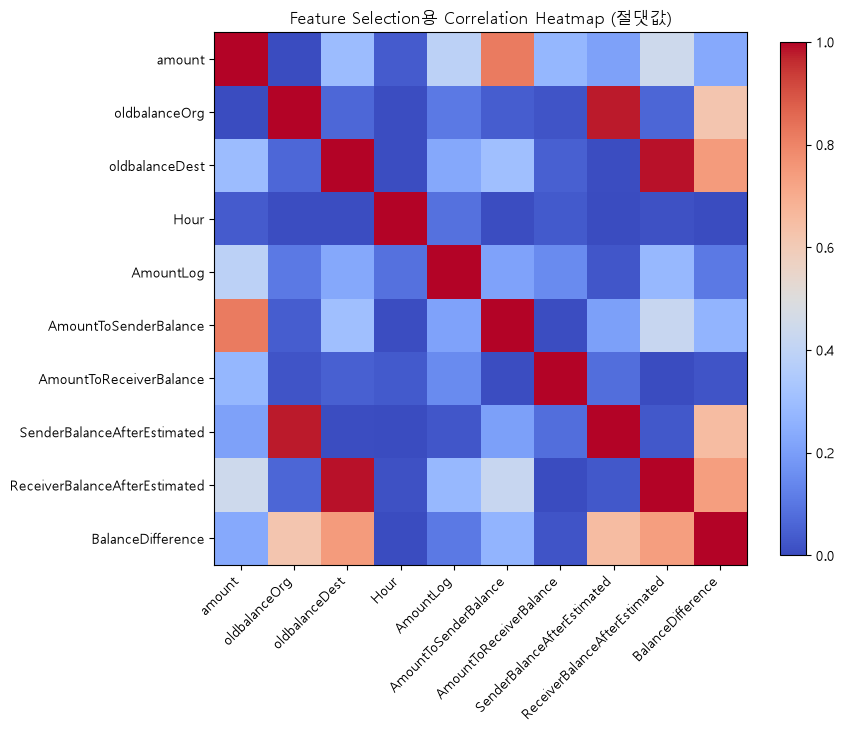

In [62]:
if DATA_AVAILABLE:
    correlation_numeric_columns = [
        "amount", "oldbalanceOrg", "oldbalanceDest", "Hour",
        "AmountLog", "AmountToSenderBalance", "AmountToReceiverBalance",
        "SenderBalanceAfterEstimated", "ReceiverBalanceAfterEstimated", "BalanceDifference",
    ]

    fs_corr_matrix = df[correlation_numeric_columns].corr().abs()

    fig, ax = plt.subplots(figsize=(9, 8))
    im = ax.imshow(fs_corr_matrix, cmap="coolwarm", vmin=0, vmax=1)
    ax.set_xticks(range(len(correlation_numeric_columns)))
    ax.set_yticks(range(len(correlation_numeric_columns)))
    ax.set_xticklabels(correlation_numeric_columns, rotation=45, ha="right")
    ax.set_yticklabels(correlation_numeric_columns)
    fig.colorbar(im, ax=ax, shrink=0.8)
    ax.set_title("Feature Selection용 Correlation Heatmap (절댓값)")
    plt.tight_layout()
    plt.show()
else:
    print("[SKIP]")


In [63]:
if DATA_AVAILABLE:
    def find_highly_correlated_pairs(corr_matrix, threshold):
        pairs = []
        columns = corr_matrix.columns
        for i in range(len(columns)):
            for j in range(i + 1, len(columns)):
                value = corr_matrix.iloc[i, j]
                if value > threshold:
                    pairs.append((columns[i], columns[j], round(value, 4)))
        return pairs


    for threshold in [0.80, 0.85, 0.90]:
        pairs = find_highly_correlated_pairs(fs_corr_matrix, threshold)
        print(f"threshold={threshold} -> 상관계수가 threshold보다 높은 쌍 {len(pairs)}개")
        for a, b, v in pairs:
            print(f"   {a}  <->  {b}   (corr={v})")
else:
    print("[SKIP]")


threshold=0.8 -> 상관계수가 threshold보다 높은 쌍 3개
   amount  <->  AmountToSenderBalance   (corr=0.8171)
   oldbalanceOrg  <->  SenderBalanceAfterEstimated   (corr=0.9789)
   oldbalanceDest  <->  ReceiverBalanceAfterEstimated   (corr=0.9872)
threshold=0.85 -> 상관계수가 threshold보다 높은 쌍 2개
   oldbalanceOrg  <->  SenderBalanceAfterEstimated   (corr=0.9789)
   oldbalanceDest  <->  ReceiverBalanceAfterEstimated   (corr=0.9872)
threshold=0.9 -> 상관계수가 threshold보다 높은 쌍 2개
   oldbalanceOrg  <->  SenderBalanceAfterEstimated   (corr=0.9789)
   oldbalanceDest  <->  ReceiverBalanceAfterEstimated   (corr=0.9872)


`amount`와 `AmountLog`, `oldbalanceOrg`와 `SenderBalanceAfterEstimated`처럼 같은 원본
변수에서 파생된 컬럼끼리는 상관관계가 높게 나타날 수 있습니다. 이런 경우 Step 4의 모델 중요도가
더 낮은 쪽을 Step 5에서 제외 후보로 검토합니다.


## Step 4. RandomForest Feature Importance

### 목적
RandomForest는 학습 과정에서 각 Feature가 불순도(오차) 감소에 얼마나 기여했는지를 계산해서
`feature_importances_`로 제공합니다. 통계적 검정과 달리, Feature들 사이의 비선형 상호작용까지
반영된 중요도입니다.


In [64]:
if DATA_AVAILABLE:
    X_train_fs, X_test_fs, y_train_fs, y_test_fs = train_test_split(
        X_fs, y_fs, test_size=0.2, random_state=RANDOM_STATE, stratify=y_fs
    )

    rf_for_selection = RandomForestClassifier(
        n_estimators=300, max_depth=16, max_samples=0.3,
        class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1,
    )
    rf_for_selection.fit(X_train_fs, y_train_fs)

    rf_importance = pd.Series(
        rf_for_selection.feature_importances_, index=X_fs.columns
    ).sort_values(ascending=False)

    print("RandomForest Feature Importance Top 15:")
    display(rf_importance.head(15))
else:
    print("[SKIP]")


RandomForest Feature Importance Top 15:


SenderBalanceAfterEstimated    0.240741
AmountToSenderBalance          0.235962
IsSenderBalanceZero            0.100820
oldbalanceOrg                  0.066389
AmountToReceiverBalance        0.045369
BalanceDifference              0.042898
AmountLog                      0.037961
IsLargeTransaction             0.030152
amount                         0.029898
type_PAYMENT                   0.027974
IsTransfer                     0.023590
type_TRANSFER                  0.023523
type_CASH_IN                   0.018296
type_CASH_OUT                  0.016574
Hour                           0.015551
dtype: float64

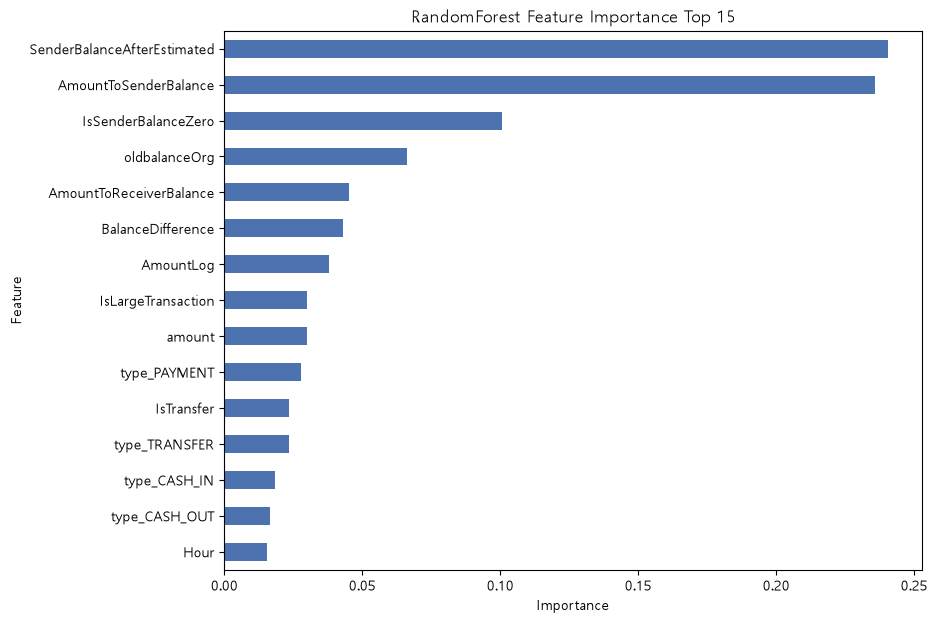

In [65]:
if DATA_AVAILABLE:
    plt.figure(figsize=(9, 7))
    rf_importance.head(15).sort_values().plot(kind="barh", color="#4C72B0")
    plt.title("RandomForest Feature Importance Top 15")
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.show()
else:
    print("[SKIP]")


## Step 5. Final Feature Selection Report

### 목적
Step 1~4에서 확인한 결과를 종합하여 최종 Feature를 결정합니다.

### 방법
One-Hot Encoding으로 나뉜 컬럼들(예: `type_TRANSFER`, `type_CASH_OUT`)을 다시 **원본 컬럼
단위**로 묶어서 RandomForest Importance를 합산합니다.


In [ ]:
if DATA_AVAILABLE:
    def original_column_of(encoded_name):
        """One-Hot Encoding된 컬럼 이름에서 원본 컬럼 이름을 찾는다."""
        for col in ALL_FEATURE_COLUMNS:
            if encoded_name == col or encoded_name.startswith(col + "_"):
                return col
        return encoded_name


    importance_df = rf_importance.reset_index()
    importance_df.columns = ["EncodedColumn", "Importance"]
    importance_df["OriginalColumn"] = importance_df["EncodedColumn"].map(original_column_of)

    original_level_importance = (
        importance_df.groupby("OriginalColumn")["Importance"].sum().sort_values(ascending=False)
    )

    print(f"Feature Selection 대상 원본 컬럼 개수: {len(original_level_importance)}")
    display(original_level_importance)
else:
    print("[SKIP]")


In [ ]:
if DATA_AVAILABLE:
    TOP_N = 10
    FINAL_FEATURE_COLUMNS = original_level_importance.head(TOP_N).index.tolist()

    print(f"최종 선정된 Feature 개수: {len(FINAL_FEATURE_COLUMNS)}")
    print(FINAL_FEATURE_COLUMNS)
else:
    print("[SKIP]")


**서비스 적용 방침**: 위 분석은 어떤 파생변수가 실제로 유용한지 확인하기 위한 진단
목적입니다. 실제 서비스(`main.py`)는 사용자가 5개 원본 값만 입력하도록 설계되어 있으므로,
Step 5에서 유용성이 낮다고 확인된 파생변수가 있다면 `feature_engineering.py`의
`FraudFeatureEngineer`에서 해당 파생변수 생성 로직을 제거하는 방식으로 반영합니다(입력
스키마는 그대로 유지됩니다).



# Chapter 6. Model Comparison


## 데이터 준비 (Train / Test Split)

모델을 학습하기 전에 데이터를 Train(학습용)과 Test(평가용)로 나눕니다. 클래스 불균형이 매우
심하므로(Chapter 2-7) `stratify=y`로 Train/Test 양쪽의 사기 비율을 원본과 동일하게 유지합니다.
전처리 기준(결측치 대체값, One-Hot Encoding 범주, 스케일링 기준)은 반드시 **Train 데이터에만**
`fit`해야 합니다. Test 데이터에 이 기준을 미리 반영하면(Data Leakage), 실제 서비스 환경보다
성능이 낙관적으로 보이는 착시가 생깁니다.

- `test_size=0.2`: 20%를 테스트용으로 남겨둡니다.
- `stratify=y`: Train/Test의 사기 비율을 원본과 동일하게 유지합니다.
- `random_state=42`: 실행할 때마다 같은 방식으로 나뉘도록 고정합니다.

이 노트북은 `feature_engineering.py`, `train_model.py`에 정의된 코드를 그대로 import해서
사용합니다. 노트북에서 새로 정의한 로직과 실제 서비스(`main.py`)가 사용하는 로직이 어긋나지
않도록 하기 위해서입니다.


In [ ]:
from feature_engineering import (
    FraudFeatureEngineer,
    RAW_INPUT_COLUMNS,
    NUMERIC_FEATURES,
    CATEGORICAL_FEATURES,
    ENGINEERED_FEATURES,
)
from train_model import (
    prepare_features,
    build_preprocessor,
    build_pipeline,
    build_candidate_models,
    evaluate_model,
    evaluate_at_threshold,
)

print("원본 입력 컬럼(RAW_INPUT_COLUMNS):", RAW_INPUT_COLUMNS)
print("파생변수(ENGINEERED_FEATURES):", ENGINEERED_FEATURES)


In [ ]:
if DATA_AVAILABLE:
    X, y = prepare_features(df)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
    )
    print("Train:", X_train.shape, " Test:", X_test.shape)
    print("Train 사기 비율(%):", round(y_train.mean() * 100, 4))
    print("Test 사기 비율(%):", round(y_test.mean() * 100, 4))
else:
    print("[SKIP]")


## 6-1. 3가지 모델 소개

| 모델 | 학습 방식 | 특징 |
|---|---|---|
| **Logistic Regression** | 입력 Feature의 선형 조합으로 사기 확률을 직접 예측 | 가장 단순하고 해석하기 쉬운 Baseline. 비선형 패턴은 스스로 찾지 못함 |
| **Random Forest** | 여러 개의 Decision Tree를 앙상블(평균) | 과적합에 강하고, 비선형 관계와 상호작용을 잘 학습함 |
| **XGBoost** | Decision Tree를 순차적으로 추가해 이전 오차를 보완(Gradient Boosting) | 정형 데이터에서 높은 성능을 보이는 경우가 많음(설치 불가 시 `HistGradientBoostingClassifier`로 대체) |

세 모델 모두 클래스 불균형 처리를 위해 `class_weight="balanced"`(Logistic Regression, Random
Forest) 또는 `scale_pos_weight`(XGBoost)를 적용합니다(Chapter 2-7 참고).

## 평가지표 계산 함수 준비

`train_model.py`의 `evaluate_model()`을 그대로 사용합니다. Accuracy, Precision, Recall, F1,
ROC-AUC, PR-AUC를 한 번에 계산합니다.


In [ ]:
if DATA_AVAILABLE:
    scale_pos_weight = (y_train == 0).sum() / max((y_train == 1).sum(), 1)
    candidate_models = build_candidate_models(scale_pos_weight)

    model_comparison_results = []
    fitted_pipelines = {}
    test_probabilities = {}
    print("비교할 모델:", list(candidate_models.keys()))
else:
    print("[SKIP]")


## 6-2. Logistic Regression

Logistic Regression은 각 Feature에 가중치(계수)를 곱해서 더한 값을 시그모이드 함수에 통과시켜
0~1 사이의 사기 확률로 변환합니다. 계수를 통해 "어떤 Feature가 사기 확률을 얼마나 높이는지"를
직접 해석할 수 있다는 장점이 있습니다.


In [ ]:
if DATA_AVAILABLE:
    name = "Logistic Regression (balanced)"
    pipeline = build_pipeline(candidate_models[name])
    pipeline.fit(X_train, y_train)

    y_proba = pipeline.predict_proba(X_test)[:, 1]
    metrics = evaluate_model(y_test, y_proba, threshold=0.5)

    print(f"=== {name} ===")
    for key, value in metrics.items():
        print(f"{key}: {value:.4f}")

    model_comparison_results.append({"Model": name, **metrics})
    fitted_pipelines[name] = pipeline
    test_probabilities[name] = y_proba
else:
    print("[SKIP]")


## 6-3. Random Forest

Random Forest는 수백 개의 Decision Tree를 각각 다른 데이터 샘플과 다른 Feature 조합으로
학습시킨 뒤, 예측 확률을 평균 내어 최종 확률을 결정합니다. 개별 트리의 과적합 문제가
평균화되어 완화됩니다.


In [ ]:
if DATA_AVAILABLE:
    name = "Random Forest (balanced)"
    pipeline = build_pipeline(candidate_models[name])
    pipeline.fit(X_train, y_train)

    y_proba = pipeline.predict_proba(X_test)[:, 1]
    metrics = evaluate_model(y_test, y_proba, threshold=0.5)

    print(f"=== {name} ===")
    for key, value in metrics.items():
        print(f"{key}: {value:.4f}")

    model_comparison_results.append({"Model": name, **metrics})
    fitted_pipelines[name] = pipeline
    test_probabilities[name] = y_proba
else:
    print("[SKIP]")


## 6-4. XGBoost

XGBoost는 Decision Tree를 한 번에 하나씩 순차적으로 추가하면서, 이전까지의 예측이 틀린
부분(잔차)을 보완하도록 학습합니다(Gradient Boosting). `xgboost`가 설치되어 있지 않은
환경에서는 scikit-learn에 내장된 `HistGradientBoostingClassifier`로 자동 대체됩니다
(`train_model.py`의 `build_candidate_models()` 참고).


In [ ]:
if DATA_AVAILABLE:
    name = [n for n in candidate_models if "XGBoost" in n or "HistGradientBoosting" in n][0]
    pipeline = build_pipeline(candidate_models[name])
    pipeline.fit(X_train, y_train)

    y_proba = pipeline.predict_proba(X_test)[:, 1]
    metrics = evaluate_model(y_test, y_proba, threshold=0.5)

    print(f"=== {name} ===")
    for key, value in metrics.items():
        print(f"{key}: {value:.4f}")

    model_comparison_results.append({"Model": name, **metrics})
    fitted_pipelines[name] = pipeline
    test_probabilities[name] = y_proba
else:
    print("[SKIP]")


## 6-5. 3개 모델 종합 비교

이제 Logistic Regression, Random Forest, XGBoost(또는 대체 모델) 3개 모델의 성능을 표와
그래프로 자세히 비교합니다.


In [ ]:
if DATA_AVAILABLE:
    model_comparison_df = pd.DataFrame(model_comparison_results)
    display(model_comparison_df)
else:
    print("[SKIP]")


In [ ]:
if DATA_AVAILABLE:
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    for i, metric in enumerate(["precision", "recall", "f1"]):
        axes[i].bar(model_comparison_df["Model"], model_comparison_df[metric], color="#4C72B0")
        axes[i].set_title(f"모델별 {metric}")
        axes[i].tick_params(axis="x", rotation=20)

    plt.tight_layout()
    plt.show()
else:
    print("[SKIP]")


## Confusion Matrix 비교

분류 모델은 회귀 모델의 "실제값 vs 예측값" 산점도 대신, **Confusion Matrix(혼동 행렬)** 로
얼마나 잘 맞추는지 확인합니다. TP(사기를 사기로), TN(정상을 정상으로)이 많고 FP/FN이 적을수록
좋은 모델입니다.


In [ ]:
from sklearn.metrics import confusion_matrix

if DATA_AVAILABLE:
    fig, axes = plt.subplots(1, len(test_probabilities), figsize=(6 * len(test_probabilities), 5))
    if len(test_probabilities) == 1:
        axes = [axes]

    for ax, (name, y_proba) in zip(axes, test_probabilities.items()):
        y_pred = (y_proba >= 0.5).astype(int)
        cm = confusion_matrix(y_test, y_pred, labels=[0, 1])

        im = ax.imshow(cm, cmap="Blues")
        ax.set_xticks([0, 1])
        ax.set_yticks([0, 1])
        ax.set_xticklabels(["Pred Normal", "Pred Fraud"])
        ax.set_yticklabels(["Actual Normal", "Actual Fraud"])
        for i in range(2):
            for j in range(2):
                ax.text(j, i, f"{cm[i, j]:,}", ha="center", va="center", color="black")
        ax.set_title(name)

    plt.tight_layout()
    plt.show()
else:
    print("[SKIP]")


### 자세한 비교 해석

**1) Precision / Recall 관점**
Recall이 높은 모델일수록 실제 사기 거래를 더 많이 잡아냅니다. Precision이 높은 모델일수록
"사기"로 예측했을 때 실제로 사기일 확률이 높습니다. 이 둘은 대체로 트레이드오프 관계이므로
Chapter 7에서 Threshold를 조정해 균형을 맞춥니다.

**2) PR-AUC 관점**
클래스 불균형이 매우 심하므로(Chapter 2-7), ROC-AUC보다 **PR-AUC** 가 모델의 실제 사기 탐지
능력을 더 잘 반영합니다. PR-AUC가 가장 높은 모델을 Chapter 7의 최종 모델 후보로 선택합니다.

**3) 실무적 해석**
Logistic Regression은 해석이 쉬워 "어떤 요인이 위험도를 높이는지" 설명이 필요한 상황에 유용할
수 있습니다. 다만 이 프로젝트는 탐지 성능이 우선이므로, PR-AUC가 가장 높은 모델을 최종 후보로
검토합니다.



# Chapter 7. Final Model (최종 모델)

Chapter 6에서 Logistic Regression, Random Forest, XGBoost 3개 모델을 실험했습니다. 이
프로젝트는 사기 거래를 놓치는 비용(미탐)이 크다고 보고, 클래스 불균형 상황에서 모델의 실제
탐지 능력을 가장 잘 보여주는 **PR-AUC를 최우선 기준**으로 최종 모델을 선정합니다.


In [ ]:
if DATA_AVAILABLE:
    best_row = model_comparison_df.loc[model_comparison_df["pr_auc"].idxmax()]
    best_model_name = best_row["Model"]
    best_pipeline = fitted_pipelines[best_model_name]
    best_proba = test_probabilities[best_model_name]

    print(f"최종 모델 후보: {best_model_name} (PR-AUC={best_row['pr_auc']:.4f} 기준)")
else:
    print("[SKIP]")


## Threshold 비교 및 선정

기본값 0.5 대신 0.40, 0.30, 0.20을 함께 비교해 Precision/Recall/F1과 False Positive/False
Negative 건수가 어떻게 달라지는지 확인합니다.


In [ ]:
THRESHOLD_CANDIDATES = [0.50, 0.40, 0.30, 0.20]

if DATA_AVAILABLE:
    threshold_rows = [evaluate_at_threshold(y_test, best_proba, t) for t in THRESHOLD_CANDIDATES]
    threshold_df = pd.DataFrame(threshold_rows)
    display(threshold_df)
else:
    print("[SKIP]")


In [ ]:
if DATA_AVAILABLE:
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(threshold_df["threshold"], threshold_df["precision"], marker="o", label="Precision")
    ax.plot(threshold_df["threshold"], threshold_df["recall"], marker="o", label="Recall")
    ax.plot(threshold_df["threshold"], threshold_df["f1"], marker="o", label="F1")
    ax.set_xlabel("Threshold")
    ax.set_ylabel("Score")
    ax.set_title("Threshold별 Precision/Recall/F1")
    ax.invert_xaxis()
    ax.legend()
    plt.tight_layout()
    plt.show()

    final_threshold = float(threshold_df.loc[threshold_df["f1"].idxmax(), "threshold"])
    print(f"선정된 Threshold: {final_threshold} (F1 최댓값 기준)")
else:
    print("[SKIP]")


**최종 Threshold 선정 규칙**: F1 Score가 가장 높은 Threshold를 최종값으로 선택합니다
(`train_model.py`의 `threshold_df["f1"].idxmax()`와 동일한 규칙). F1은 Precision과 Recall의
조화 평균이므로, 어느 한쪽으로 극단적으로 치우치지 않으면서도 사기 탐지 성능을 균형 있게
반영합니다. 운영 환경에서 미탐 비용이 오탐 비용보다 훨씬 크다고 판단되면, F1 대신 Recall을
우선하는 더 낮은 Threshold를 선택할 수도 있습니다.


## 최종 모델 저장

`train_model.py`와 완전히 동일한 방식으로 최종 Pipeline과 메타데이터를 저장합니다. 이 노트북이
저장하는 파일이 곧 `main.py`가 실제로 불러와 서비스하는 파일입니다(별도의 노트북 전용 모델을
만들지 않습니다).


In [ ]:
import joblib

MODEL_DIR = "../models"
PIPELINE_PATH = os.path.join(MODEL_DIR, "fraud_detection_pipeline.pkl")
METADATA_PATH = os.path.join(MODEL_DIR, "model_metadata.json")

if DATA_AVAILABLE:
    os.makedirs(MODEL_DIR, exist_ok=True)

    final_metrics = evaluate_model(y_test, best_proba, threshold=final_threshold)

    try:
        joblib.dump(best_pipeline, PIPELINE_PATH)
        print(f"모델 저장 완료: {PIPELINE_PATH}")

        metadata = {
            "project": "04-card-fraud-ai",
            "service_name": "Card Fraud Detection AI",
            "dataset": "PaySim",
            "model_name": best_model_name,
            "model_version": "1.0.0",
            "target": "isFraud",
            "input_features": RAW_INPUT_COLUMNS,
            "engineered_features": ENGINEERED_FEATURES,
            "threshold": final_threshold,
            "metrics": {k: round(v, 6) for k, v in final_metrics.items()},
            "train_rows": int(len(X_train)),
            "test_rows": int(len(X_test)),
            "random_state": RANDOM_STATE,
        }
        with open(METADATA_PATH, "w", encoding="utf-8") as f:
            json.dump(metadata, f, indent=2, ensure_ascii=False)
        print(f"메타데이터 저장 완료: {METADATA_PATH}")
    except Exception as error:
        print("모델 저장 중 오류가 발생했습니다:", error)
else:
    print("[SKIP] 데이터가 없어 모델을 저장하지 않습니다.")



# Chapter 8. Research Report (연구 보고서)

- 지금까지의 전체 분석 과정을 하나의 보고서로 요약할 수 있다.


In [ ]:
if DATA_AVAILABLE:
    report = f"""
# Card Fraud Detection AI - EDA / Feature Engineering / Model Comparison 연구 보고서

## 1. 프로젝트 개요

- 데이터셋: PaySim (`ai-server/data/paysim.csv`, {len(df):,}건, {df.shape[1]}개 컬럼)
- Target: `isFraud` (사기 거래 여부) -> 이진 분류(Binary Classification) 문제
- 이 보고서는 Feature Selection을 5단계로 진행하고, 모델 비교를 Logistic Regression / Random
  Forest / XGBoost(또는 대체 모델) 3개로 테스트하였다.

## 2. EDA 결과 요약

- 전체 {len(df):,}건 중 사기 거래는 {fraud_count:,}건으로 전체의 {fraud_ratio:.4f}%에 불과한
  극단적인 클래스 불균형이 존재한다.
- 거래 유형 중 `{top_type}`의 사기 비율이 {top_type_ratio:.4f}%로 가장 높았다.
- 시간대 중 {peak_fraud_hour}시의 사기 비율이 {peak_fraud_hour_ratio:.4f}%로 가장 높았다.

## 3. Hypothesis (가설)

Chapter 3에서 EDA 결과를 근거로 7개의 가설을 수립했다.

## 4. Feature Engineering 결과

Chapter 4에서 11개의 파생변수(TimeOfDay, AmountLog, AmountToSenderBalance,
AmountToReceiverBalance, SenderBalanceAfterEstimated, ReceiverBalanceAfterEstimated,
IsSenderBalanceZero, IsLargeTransaction, IsTransfer, IsCashOut, BalanceDifference)를
생성했다.

## 5. Feature Selection 결과

Variance Threshold -> Quasi Constant -> Correlation Analysis -> RandomForest Importance ->
Final Report의 5단계를 적용한 결과, 원본 {len(FE_BASELINE_COLUMNS)}개 + 파생 11개 =
{len(ALL_FEATURE_COLUMNS)}개 Feature 중 원본 컬럼 단위 중요도 상위 {len(FINAL_FEATURE_COLUMNS)}개를
확인했다. 다만 실제 서비스는 사용자가 5개 원본 값만 입력하도록 설계되어 있으므로, 이 분석은
`FraudFeatureEngineer`가 생성하는 파생변수의 유용성을 검증하는 진단 목적으로 사용한다.

## 6. Model Comparison 결과

Logistic Regression, Random Forest, XGBoost(또는 대체 모델) 3개 모델을 동일한 Train/Test
분할과 동일한 Pipeline으로 비교했다.

## 7. 최종 모델

- **최종 선정 모델**: {best_model_name}
- **선정 기준**: PR-AUC 최우선 (클래스 불균형이 심할수록 ROC-AUC보다 신뢰할 수 있는 지표)
- **선정된 Threshold**: {final_threshold} (F1 최댓값 기준)
- **최종 성능**:
  - Precision: {final_metrics['precision']:.4f}
  - Recall: {final_metrics['recall']:.4f}
  - F1: {final_metrics['f1']:.4f}
  - ROC-AUC: {final_metrics['roc_auc']:.4f}
  - PR-AUC: {final_metrics['pr_auc']:.4f}

## 8. FastAPI 적용 시 주의사항

1. 저장된 `fraud_detection_pipeline.pkl`은 `RAW_INPUT_COLUMNS`
   ({len(RAW_INPUT_COLUMNS)}개: {', '.join(RAW_INPUT_COLUMNS)})만 입력받으면 되며, 파생변수는
   `FraudFeatureEngineer`가 Pipeline 내부에서 자동으로 생성한다.
2. `newbalanceOrig`, `newbalanceDest`, `isFlaggedFraud`, 고객 식별자는 예측 시점에 사용할 수
   없거나 데이터 누수를 유발하므로 입력에 포함하지 않는다.
3. 예측 확률은 `threshold`({final_threshold}) 기준으로 Suspicious/Normal을 나누며, 화면에는
   사기를 확정하는 표현 대신 "추가 확인이 필요한 거래" 같은 참고용 표현을 사용한다.
4. 이 결과는 학습에 사용한 데이터/기간에 한정되므로, 실제 서비스에 적용하려면 최신 데이터로
   주기적인 재학습과 Threshold 재검토가 필요하다.

"""
    display(Markdown(report))
else:
    print("[SKIP] 데이터가 없어 연구 보고서를 생성할 수 없습니다.")
    print()
    print("data/ 폴더에 PaySim 데이터를 추가한 뒤 이 노트북을 처음부터(Run All) 다시 실행하면,")
    print("위 코드가 실제 결과를 바탕으로 연구 보고서를 자동 생성합니다.")
    print()
    print("지금까지 구현된 내용(코드 구조 기준 요약)")
    print("Chapter 2  EDA: 데이터 로딩/품질 점검/클래스 불균형/유형·금액·잔액·시간 분석/상관관계/이상치/Findings")
    print("Chapter 3  Hypothesis: EDA 근거 기반 7개 가설 수립")
    print("Chapter 4  Feature Engineering: 11개 파생변수 생성 + Baseline 대비 성능 비교(quick_evaluate)")
    print("Chapter 5  Feature Selection: Variance Threshold / Quasi Constant / Correlation / RF Importance / Final Report")
    print("Chapter 6  Model Comparison: Logistic Regression / Random Forest / XGBoost 비교 + Confusion Matrix")
    print("Chapter 7  Final Model: PR-AUC 기준 모델 선정 + Threshold 비교 + Pipeline/메타데이터 저장")
    print("Chapter 8  Research Report: 위 결과를 종합한 보고서 자동 생성 (본 셀)")
    print()
    print("데이터 추가 후 Run All을 실행하면 위 모든 항목의 실제 수치가 채워집니다.")
